# Entregable 2: Windows Defender detector

Entregable realizado por Osval Hernández, Jorge Espina y Jon Mikel García Zurutuza

## 1. Importación de librerías, primera visualización de dataframe, comprobación de duplicados y target = "HasDetections"

In [ ]:
# IMPORTAMOS LIBRERÍAS

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn import set_config
set_config(transform_output="pandas") #Para mantener el output de los transformers como DataFrame, lo que facilita la inspección y depuración de los datos a lo largo del pipeline.

In [2]:
#csv_path = r"D:\Documentos\Nuclio\Entregable_2\sample_mmp.csv"
csv_path = r"C:\Users\jonmi\Documents\Nuclio\nuclio-datascience_AI\Entregable_2\sample_mmp.csv"
#csv_path = r"C:\Users\JGarcia94\OneDrive - Lear Corporation\Documents\GITHub_Repository\nuclio-datascience_AI\Entregable_2\sample_mmp.csv"
df = pd.read_csv(csv_path, dtype={"PuaMode": 'category', "Census_ProcessorClass": "category"})

In [3]:
df.shape

(500000, 84)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 84 columns):
 #   Column                                             Non-Null Count   Dtype   
---  ------                                             --------------   -----   
 0   Unnamed: 0                                         500000 non-null  int64   
 1   MachineIdentifier                                  500000 non-null  object  
 2   ProductName                                        500000 non-null  object  
 3   EngineVersion                                      500000 non-null  object  
 4   AppVersion                                         500000 non-null  object  
 5   AvSigVersion                                       500000 non-null  object  
 6   IsBeta                                             500000 non-null  int64   
 7   RtpStateBitfield                                   498168 non-null  float64 
 8   IsSxsPassiveMode                                   500000 non-nu

In [5]:
df.head().T

,0,1,2,3,4
Unnamed: 0,8427007,8829090,2731904,1359513,236059
MachineIdentifier,f1cd864e97bae82bdf96523e1a539121,fd5ba6f5b75325ec0423a6c67cc75942,4e628391e7cc7c482fb3286f486dbd25,270a2e9d028144a4df12a9e3da79fba5,06ca8fa8d32c2abdc5b3577d676b3269
ProductName,win8defender,win8defender,win8defender,win8defender,win8defender
EngineVersion,1.1.15100.1,1.1.15100.1,1.1.15100.1,1.1.15200.1,1.1.15200.1
AppVersion,4.18.1807.18075,4.18.1807.18075,4.9.10586.1106,4.18.1807.18075,4.18.1807.18075
...,...,...,...,...,...
Census_IsPenCapable,0,0,1,0,0
Census_IsAlwaysOnAlwaysConnectedCapable,0.0,0.0,0.0,0.0,0.0
Wdft_IsGamer,0.0,1.0,0.0,0.0,1.0
Wdft_RegionIdentifier,11.0,3.0,15.0,15.0,13.0


In [6]:
pd.set_option('display.max_rows', 100)

In [7]:
numeric_describe = df.describe(include='number').T
numeric_describe

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,500000.0,4.458888e+06,2.575619e+06,2.0,2227692.50,4461367.5,6.690936e+06,8.921471e+06
IsBeta,500000.0,2.000000e-06,1.414214e-03,0.0,0.00,0.0,0.000000e+00,1.000000e+00
RtpStateBitfield,498168.0,6.846207e+00,1.023049e+00,0.0,7.00,7.0,7.000000e+00,3.500000e+01
IsSxsPassiveMode,500000.0,1.724200e-02,1.301720e-01,0.0,0.00,0.0,0.000000e+00,1.000000e+00
DefaultBrowsersIdentifier,24061.0,1.652825e+03,1.004754e+03,1.0,788.00,1632.0,2.381000e+03,3.209000e+03
AVProductStatesIdentifier,498062.0,4.785091e+04,1.402309e+04,3.0,49480.00,53447.0,5.344700e+04,7.049200e+04
AVProductsInstalled,498062.0,1.326763e+00,5.229999e-01,1.0,1.00,1.0,2.000000e+00,5.000000e+00
AVProductsEnabled,498062.0,1.020714e+00,1.666080e-01,0.0,1.00,1.0,1.000000e+00,4.000000e+00
HasTpm,500000.0,9.878160e-01,1.097068e-01,0.0,1.00,1.0,1.000000e+00,1.000000e+00
CountryIdentifier,500000.0,1.080375e+02,6.306854e+01,1.0,51.00,97.0,1.620000e+02,2.220000e+02


In [8]:
object_describe = df.describe(include='object').T
object_describe

,count,unique,top,freq
MachineIdentifier,500000,500000,fba7138931e22f004ee389c236b98254,1
ProductName,500000,3,win8defender,494604
EngineVersion,500000,53,1.1.15200.1,216491
AppVersion,500000,95,4.18.1807.18075,288809
AvSigVersion,500000,6455,1.273.1420.0,5771
Platform,500000,4,windows10,483048
Processor,500000,3,x64,454423
OsVer,500000,21,10.0.0.0,483830
OsPlatformSubRelease,500000,9,rs4,220779
OsBuildLab,499999,453,17134.1.amd64fre.rs4_release.180410-1804,206436


In [9]:
df[df.duplicated(keep="first")]

,Unnamed: 0,MachineIdentifier,ProductName,EngineVersion,AppVersion,AvSigVersion,IsBeta,RtpStateBitfield,IsSxsPassiveMode,DefaultBrowsersIdentifier,...,Census_FirmwareVersionIdentifier,Census_IsSecureBootEnabled,Census_IsWIMBootEnabled,Census_IsVirtualDevice,Census_IsTouchEnabled,Census_IsPenCapable,Census_IsAlwaysOnAlwaysConnectedCapable,Wdft_IsGamer,Wdft_RegionIdentifier,HasDetections


In [10]:
df.isna().sum()

Unnamed: 0                                                0
MachineIdentifier                                         0
ProductName                                               0
EngineVersion                                             0
AppVersion                                                0
AvSigVersion                                              0
IsBeta                                                    0
RtpStateBitfield                                       1832
IsSxsPassiveMode                                          0
DefaultBrowsersIdentifier                            475939
AVProductStatesIdentifier                              1938
AVProductsInstalled                                    1938
AVProductsEnabled                                      1938
HasTpm                                                    0
CountryIdentifier                                         0
CityIdentifier                                        18240
OrganizationIdentifier                  

Se deciden eliminar las columnas Machine Identifier (ID de máquina cardinalidad = 1) y Unnamed: 0 (sin información).

In [11]:
df.drop(columns = ['Unnamed: 0', 'MachineIdentifier'], axis=1, inplace=True)

### 1.1. Definición de target

In [12]:
target = "HasDetections"

### 1.2. Adición de columnas por cálculo de otras

In [13]:
# --- Feature Engineering ---
# Operaciones deterministas (sin estadísticos) → no introduce data leakage


# 1. Ratio AV: proporción de antivirus habilitados sobre instalados
df["av_enabled_ratio"] = df["AVProductsEnabled"] / df["AVProductsInstalled"]

# 2. Resolución total de pantalla
df["screen_resolution"] = (
    df["Census_InternalPrimaryDisplayResolutionHorizontal"] *
    df["Census_InternalPrimaryDisplayResolutionVertical"]
)

# 3. Versión mayor de AppVersion
df["app_version_major"] = pd.to_numeric(
    df["AppVersion"].str.split(".").str[0], errors="coerce"
)

print(f"Shape tras FE: {df.shape}")


Shape tras FE: (500000, 85)


## 2. Separación validación, test y train

Se empleará el método stratification para mantener la distribución del target ya que está balanceado

In [14]:
from sklearn.model_selection import train_test_split

X = df.drop(target, axis=1)
y = df[target]

# Step 1: Create Validation set (15%)
X_temp, X_val, y_temp, y_val = train_test_split(
    X, y,
    test_size=75000,  # 15% of total
    stratify=y,
    random_state=42
)

# Step 2: Create TEST set (15% of total)

X_train, X_test, y_train, y_test = train_test_split(
    X_temp, y_temp,
    test_size=75000, # 15% of total
    stratify=y_temp,
    random_state=42
)

In [15]:
print("Train:", y_train.value_counts(normalize=True))
print("Val:", y_val.value_counts(normalize=True))
print("Test:", y_test.value_counts(normalize=True))

Train: HasDetections
0    0.500094
1    0.499906
Name: proportion, dtype: float64
Val: HasDetections
0    0.500093
1    0.499907
Name: proportion, dtype: float64
Test: HasDetections
0    0.500093
1    0.499907
Name: proportion, dtype: float64


In [16]:
np.save("train_idx.npy", X_train.index)
np.save("val_idx.npy", X_val.index)
np.save("test_idx.npy", X_test.index)

In [17]:
df_train = X_train.copy()
df_train[target] = y_train

## 3. EDA + Gestión de nulos

Se decide crear la clase EDAInspector con el objetivo de facilitar el análisis del dataset.

In [18]:
class EDAInspector:
    #DecisionTree version
    def __init__(self, df):
        self.df = df.copy()
        # self.refresh_types()
    
        # Lists to track treated columns
        self.fill_constant_list = []
        self.fill_mean_list = []
        self.fill_median_list = []
        self.fill_missing_list = []
        #self.missing_indicator_list = []
        self.drop_columns = []
        #self.dropped_nanRows_columns = []
    
    
    @property
    def numeric_cols(self):
        return self.df.select_dtypes(include=np.number).columns.tolist()

    @property
    def object_cols(self):
        return self.df.select_dtypes(include=["object"]).columns.tolist()

    @property
    def category_cols(self):
        return self.df.select_dtypes(include=["category"]).columns.tolist()

    @property
    def bool_cols(self):
        return self.df.select_dtypes(include=["bool"]).columns.tolist()

    @property
    def n_rows(self):
        return len(self.df)

    
    @property #se emplea como propiedad para que se ejecute automáticamente al acceder a ella, sin necesidad de llamarla como método
    def high_cardinality_cols(self):

        cat_cols = self.object_cols + self.category_cols

        unique_counts = self.df[cat_cols].nunique()

        return unique_counts[unique_counts > 100].index.tolist()
    
    # ----------------------------
    # NUMERIC SUMMARY
    # ----------------------------
    
    def numeric_summary(self):
        
        summary = pd.DataFrame({
            "dtype": self.df[self.numeric_cols].dtypes,
            "unique_values": self.df[self.numeric_cols].nunique(),
            "pct_unique": self.df[self.numeric_cols].nunique() / self.n_rows * 100,
            "null_pct": self.df[self.numeric_cols].isnull().mean() * 100,
            "min": self.df[self.numeric_cols].min(),
            "max": self.df[self.numeric_cols].max()
        })
        
        summary["possible_id"] = summary["pct_unique"] > 90
        
        summary["likely_categorical"] = (
            (summary["unique_values"] < 60) &
            (summary["pct_unique"] < 5)
        )
        
        # Store likely_categorical columns as a list for easy access
        self.likely_categorical_cols = summary[summary["likely_categorical"]].index.tolist()
        
        return summary.sort_values("pct_unique", ascending=False)
    
    
    # ----------------------------
    # CATEGORICAL SUMMARY
    # ----------------------------
    
    def categorical_summary(self):

        cat_cols = self.object_cols + self.category_cols

        summary = pd.DataFrame({
            "dtype": self.df[cat_cols].dtypes,
            "unique_values": self.df[cat_cols].nunique(),
            "pct_unique": self.df[cat_cols].nunique() / self.n_rows * 100,
            "null_pct": self.df[cat_cols].isnull().mean() * 100
        })

        summary["high_cardinality"] = summary.index.isin(self.high_cardinality_cols)

        return summary.sort_values("unique_values", ascending=False)
    
    # ----------------------------
    # Identifier/Version etc DETECTOR in numeric columns
    # ---------------------------- 
    
    def detect_identifier_columns(self, keywords=None):
    
        if keywords is None:
            keywords = ["identifier"]
        
        self.identifier_cols = [
            col for col in self.numeric_cols
            if any(k in col.lower() for k in keywords)
        ]
        
        print(f"Detected {len(self.identifier_cols)} identifier columns:")
        #print(self.identifier_cols)
        
        return self.identifier_cols
 
    
    # ----------------------------
    # CONVERT NUMERIC → CATEGORY
    # ----------------------------
    
    def convert_to_category(self, columns, verbose=True):
        
        if isinstance(columns, str):
            columns = [columns]
        
        for col in columns:
            if col in self.df.columns:
                self.df[col] = self.df[col].astype("category")
        
        #self.refresh_types()
        
        if verbose:
            print(len(columns), " converted to category:", columns)
    
    
    # ----------------------------
    # CONVERT TO NUMERIC
    # ----------------------------
    
    def convert_to_numeric(self, columns, verbose=True):
        
        if isinstance(columns, str):
            columns = [columns]
        
        for col in columns:
            if col in self.df.columns:
                self.df[col] = pd.to_numeric(self.df[col], errors="coerce")
        
        #self.refresh_types()
        
        if verbose:
            print(len(columns), " converted to numeric:", columns)



    def null_summary(self, only_nulls = False):
        self.summary = pd.DataFrame({
            "dtype": self.df.dtypes,
            "null_count": self.df.isnull().sum(),
            "pct_nulls": self.df.isnull().mean() * 100,
            "unique_values": self.df.nunique(),
            "pct_unique": self.df.nunique() / self.n_rows * 100
        })
        
        result = self.summary.sort_values("pct_nulls", ascending=False)
        
        if only_nulls:
            result = result[result["null_count"]>0]
            
        return result
    
    def apply_drops(self, columns=None, verbose=True):
        """
        Drop columns from the DataFrame.
        
        Parameters
        ----------
        columns : str or list, optional
            Column or list of columns to drop. If None, drops whatever is already
            stored in self.drop_columns.
        """

        # Normalize input
        if columns is not None:
            if isinstance(columns, str):
                columns = [columns]

            # Add new columns to drop list
            self.drop_columns.extend(columns)

        # Remove duplicates
        self.drop_columns = list(set(self.drop_columns))

        # Determine which columns actually exist in df
        cols_to_drop = [c for c in self.drop_columns if c in self.df.columns]

        if cols_to_drop:
            self.df.drop(columns=cols_to_drop, inplace=True)
            if verbose:
                print(f"Dropped {len(cols_to_drop)} columns: {cols_to_drop}")
        else:
            if verbose:
                print("No matching columns to drop.")

    # Refresh internal type lists
    #self.refresh_types()
    
       
    def droppable_columns(
        self,
        null_high_thresh=95,
        null_low_thresh=0.5,
        cardinality_threshold=90
    ):
        """
        Classifies columns into:
        - high null percentage → drop
        - high cardinality → drop
        - low nulls → fill (categorical → 'Missing', numeric → median)
        """

        null_sum = self.null_summary()

        # -------------------------
        # 1. HIGH NULL COLUMNS → DROP
        # -------------------------
        high_null_cols = null_sum[null_sum["pct_nulls"] > null_high_thresh].index.tolist()

        # -------------------------
        # 2. HIGH CARDINALITY → DROP
        # -------------------------
        high_cardinality_cols = null_sum[null_sum["pct_unique"] > cardinality_threshold].index.tolist()

        # -------------------------
        # 3. LOW NULL COLUMNS → FILL
        # -------------------------
        low_null_cols = null_sum[
            (null_sum["pct_nulls"] > 0) &
            (null_sum["pct_nulls"] < null_low_thresh)
        ].index.tolist()

        # Split low-null columns by dtype
        low_null_categorical = [c for c in low_null_cols if c in self.object_cols + self.category_cols]
        low_null_numeric = [c for c in low_null_cols if c in self.numeric_cols]

        # -------------------------
        # 4. Apply actions
        # -------------------------

        # Drop high-null and high-cardinality columns
        cols_to_drop = high_null_cols + high_cardinality_cols
        if cols_to_drop:
            self.drop_columns.extend(cols_to_drop)

        # Fill categorical with "Missing" because DecisionTree handles it
        for col in low_null_categorical:
            self.fill_missing_list.append(col)

        # Fill numeric with median
        for col in low_null_numeric:
            self.fill_median_list.append(col)

        # Apply the drops immediately
        self.apply_drops(verbose=False)
        
        # -------------------------
        # 5. Logging
        # -------------------------
        print(f"{len(high_null_cols)} columns dropped due to high null percentage: {high_null_cols}")
        print(f"{len(high_cardinality_cols)} columns dropped due to high cardinality: {high_cardinality_cols}")
        print(f"{len(low_null_categorical)} categorical columns added to fill_missing_list : {low_null_categorical}")
        print(f"{len(low_null_numeric)} numeric columns added to fill_median_list: {low_null_numeric}")

        #self.refresh_types()
      
    
    def imputation_summary(self):
        """
        Build a summary DataFrame showing:
        - columns dropped
        - columns filled with constant / mean / median
        - columns still containing nulls (not treated)
        - remaining untouched columns
        """

        # Ensure lists are flat
        drop = sorted(set(self.drop_columns))
        fill_constant = sorted(set(self.fill_constant_list))
        fill_mean = sorted(set(self.fill_mean_list))
        fill_median = sorted(set(self.fill_median_list))
        fill_missing = sorted(set(self.fill_missing_list))

        # Columns with nulls that were NOT treated
        treated = set(drop + fill_constant + fill_mean + fill_median + fill_missing)
        null_cols = self.df.columns[self.df.isnull().any()].tolist()
        self.remaining_null_cols = sorted(set(null_cols) - treated)

        # Untouched columns = all columns - treated - remaining_null_cols
        self.untouched = sorted(set(self.df.columns) - treated - set(self.remaining_null_cols))

        # Build dictionary
        summary_dict = {
            "drop_columns": drop,
            "fill_constant": fill_constant,
            "fill_mean": fill_mean,
            "fill_median": fill_median,
            "fill_missing": fill_missing,
            "remaining_null_columns": self.remaining_null_cols,
            "untouched_columns": self.untouched
        }

        # Build DataFrame
        rows = []
        for category, cols in summary_dict.items():
            if cols:
                dtypes = sorted({str(self.df[col].dtype) for col in cols if col in self.df.columns})
            else:
                dtypes = []

            rows.append({
                "category": category,
                "n_columns": len(cols),
                "columns": cols,
                "dtypes": dtypes
            })

        return pd.DataFrame(rows)

        
    def get_data(self):
        return self.df




### 3.1. Inspector1 para primer EDA

- Clasificación de columnas numéricas que tengan características de columnas categóricas.

- Clasificación como categóricas las columnas con la palabra 'identifier' en el nombre.

- Descarte de columnas por alta cardinalidad o alto % de nulos.

In [19]:
inspector1 = EDAInspector(df_train)

In [20]:
inspector1.numeric_summary()

,dtype,unique_values,pct_unique,null_pct,min,max,possible_id,likely_categorical
Census_SystemVolumeTotalCapacity,float64,112810,32.231429,0.595143,9689.0,2.859558e+07,False,False
Census_OEMModelIdentifier,float64,33296,9.513143,1.150000,22.0,3.454930e+05,False,False
CityIdentifier,float64,31181,8.908857,3.626000,7.0,1.679580e+05,False,False
Census_FirmwareVersionIdentifier,float64,20897,5.970571,1.812857,10.0,7.209100e+04,False,False
AVProductStatesIdentifier,float64,4466,1.276000,0.386000,3.0,7.049200e+04,False,False
Census_InternalBatteryNumberOfCharges,float64,4031,1.151714,3.003143,0.0,4.294967e+09,False,False
Census_ProcessorModelIdentifier,float64,2127,0.607714,0.469143,19.0,4.472000e+03,False,False
Census_OEMNameIdentifier,float64,1406,0.401714,1.068571,74.0,6.143000e+03,False,False
Census_PrimaryDiskTotalCapacity,float64,906,0.258857,0.595143,10240.0,2.859591e+07,False,False
screen_resolution,float64,663,0.189429,0.533429,1.0,3.317760e+07,False,False


In [21]:
inspector1.likely_categorical_cols

['IsBeta',
 'RtpStateBitfield',
 'IsSxsPassiveMode',
 'AVProductsInstalled',
 'AVProductsEnabled',
 'HasTpm',
 'OrganizationIdentifier',
 'OsBuild',
 'OsSuite',
 'IsProtected',
 'AutoSampleOptIn',
 'SMode',
 'Firewall',
 'UacLuaenable',
 'Census_ProcessorCoreCount',
 'Census_ProcessorManufacturerIdentifier',
 'Census_HasOpticalDiskDrive',
 'Census_OSBuildNumber',
 'Census_OSInstallLanguageIdentifier',
 'Census_IsPortableOperatingSystem',
 'Census_IsFlightingInternal',
 'Census_IsFlightsDisabled',
 'Census_ThresholdOptIn',
 'Census_IsSecureBootEnabled',
 'Census_IsWIMBootEnabled',
 'Census_IsVirtualDevice',
 'Census_IsTouchEnabled',
 'Census_IsPenCapable',
 'Census_IsAlwaysOnAlwaysConnectedCapable',
 'Wdft_IsGamer',
 'Wdft_RegionIdentifier',
 'av_enabled_ratio',
 'app_version_major',
 'HasDetections']

In [22]:
inspector1.convert_to_category(inspector1.likely_categorical_cols)

34  converted to category: ['IsBeta', 'RtpStateBitfield', 'IsSxsPassiveMode', 'AVProductsInstalled', 'AVProductsEnabled', 'HasTpm', 'OrganizationIdentifier', 'OsBuild', 'OsSuite', 'IsProtected', 'AutoSampleOptIn', 'SMode', 'Firewall', 'UacLuaenable', 'Census_ProcessorCoreCount', 'Census_ProcessorManufacturerIdentifier', 'Census_HasOpticalDiskDrive', 'Census_OSBuildNumber', 'Census_OSInstallLanguageIdentifier', 'Census_IsPortableOperatingSystem', 'Census_IsFlightingInternal', 'Census_IsFlightsDisabled', 'Census_ThresholdOptIn', 'Census_IsSecureBootEnabled', 'Census_IsWIMBootEnabled', 'Census_IsVirtualDevice', 'Census_IsTouchEnabled', 'Census_IsPenCapable', 'Census_IsAlwaysOnAlwaysConnectedCapable', 'Wdft_IsGamer', 'Wdft_RegionIdentifier', 'av_enabled_ratio', 'app_version_major', 'HasDetections']


In [23]:
inspector1.detect_identifier_columns()

Detected 13 identifier columns:


['DefaultBrowsersIdentifier',
 'AVProductStatesIdentifier',
 'CountryIdentifier',
 'CityIdentifier',
 'GeoNameIdentifier',
 'LocaleEnglishNameIdentifier',
 'IeVerIdentifier',
 'Census_OEMNameIdentifier',
 'Census_OEMModelIdentifier',
 'Census_ProcessorModelIdentifier',
 'Census_OSUILocaleIdentifier',
 'Census_FirmwareManufacturerIdentifier',
 'Census_FirmwareVersionIdentifier']

In [24]:
inspector1.convert_to_category(inspector1.identifier_cols)

13  converted to category: ['DefaultBrowsersIdentifier', 'AVProductStatesIdentifier', 'CountryIdentifier', 'CityIdentifier', 'GeoNameIdentifier', 'LocaleEnglishNameIdentifier', 'IeVerIdentifier', 'Census_OEMNameIdentifier', 'Census_OEMModelIdentifier', 'Census_ProcessorModelIdentifier', 'Census_OSUILocaleIdentifier', 'Census_FirmwareManufacturerIdentifier', 'Census_FirmwareVersionIdentifier']


In [25]:
inspector1.droppable_columns()

3 columns dropped due to high null percentage: ['PuaMode', 'Census_ProcessorClass', 'DefaultBrowsersIdentifier']
0 columns dropped due to high cardinality: []
15 categorical columns added to fill_missing_list : ['Census_ProcessorModelIdentifier', 'Census_ProcessorCoreCount', 'Census_ProcessorManufacturerIdentifier', 'AVProductsEnabled', 'AVProductStatesIdentifier', 'av_enabled_ratio', 'AVProductsInstalled', 'IsProtected', 'RtpStateBitfield', 'Census_IsVirtualDevice', 'Census_PrimaryDiskTypeName', 'UacLuaenable', 'Census_ChassisTypeName', 'GeoNameIdentifier', 'OsBuildLab']
0 numeric columns added to fill_median_list: []


In [26]:
inspector1.numeric_summary()

,dtype,unique_values,pct_unique,null_pct,min,max,possible_id,likely_categorical
Census_SystemVolumeTotalCapacity,float64,112810,32.231429,0.595143,9689.0,2.859558e+07,False,False
Census_InternalBatteryNumberOfCharges,float64,4031,1.151714,3.003143,0.0,4.294967e+09,False,False
Census_PrimaryDiskTotalCapacity,float64,906,0.258857,0.595143,10240.0,2.859591e+07,False,False
screen_resolution,float64,663,0.189429,0.533429,1.0,3.317760e+07,False,False
Census_InternalPrimaryDiagonalDisplaySizeInInches,float64,483,0.138000,0.534000,4.9,1.420000e+02,False,False
Census_TotalPhysicalRAM,float64,449,0.128286,0.896857,512.0,3.932160e+05,False,False
Census_InternalPrimaryDisplayResolutionVertical,float64,420,0.120000,0.533429,-1.0,4.320000e+03,False,False
Census_InternalPrimaryDisplayResolutionHorizontal,float64,374,0.106857,0.533429,-1.0,1.152000e+04,False,False
Census_OSBuildRevision,int64,237,0.067714,0.000000,0.0,1.906900e+04,False,False


In [28]:
inspector1.categorical_summary()

,dtype,unique_values,pct_unique,null_pct,high_cardinality
Census_OEMModelIdentifier,category,33296,9.513143,1.150000,True
CityIdentifier,category,31181,8.908857,3.626000,True
Census_FirmwareVersionIdentifier,category,20897,5.970571,1.812857,True
AvSigVersion,object,5925,1.692857,0.000000,True
AVProductStatesIdentifier,category,4466,1.276000,0.386000,True
Census_ProcessorModelIdentifier,category,2127,0.607714,0.469143,True
Census_OEMNameIdentifier,category,1406,0.401714,1.068571,True
OsBuildLab,object,431,0.123143,0.000286,True
Census_OSVersion,object,292,0.083429,0.000000,True
Census_FirmwareManufacturerIdentifier,category,276,0.078857,2.072571,True


### 3.2. Función Check signal

Esta función nos ayuda a comprobar el impacto de una columna en la variable objetivo, tanto para valores nulos como para los diferentes valores de la columna.

In [30]:
#This functions helps us check the impact of a column on the target variable, both for null values and for the different values of the column.

def check_signal(df, col, target=target):
    print("Value counts:")
    print(df[col].value_counts(dropna=False, normalize=True))
    
    print("\nNull impact:")
    print(df.groupby(df[col].isnull())[target].mean())
    
    print("\nValue impact:")
    print(df.groupby(col)[target].mean().sort_values())

### 3.3. Columnas con >30% y <95% nulos

#### Census_IsFlightingInternal: 
Es una propiedad del servicio "Device Census", pero no un toggle que cambie el comportamiento de Windows defender (no muestra posibles diferencias en detección de Malware). Dado el alto porcentaje de nulos y que casi no tiene variabilidad en los valores nulos se elimina

In [31]:
check_signal(df_train, 'Census_IsFlightingInternal')

Value counts:
Census_IsFlightingInternal
NaN    0.830383
0.0    0.169614
1.0    0.000003
Name: proportion, dtype: float64

Null impact:
Census_IsFlightingInternal
False    0.485935
True     0.502759
Name: HasDetections, dtype: float64

Value impact:
Census_IsFlightingInternal
1.0    0.000000
0.0    0.485943
Name: HasDetections, dtype: float64


In [32]:
inspector1.drop_columns.append('Census_IsFlightingInternal')

#### Drop Census_InternalBatteryType.
La eliminamos por su alta cardinalidad

In [33]:
#Add missing category
df_train['Census_InternalBatteryType'].value_counts(dropna = False, normalize = True)

Census_InternalBatteryType
NaN     0.711549
lion    0.226729
li-i    0.027700
#       0.020306
lip     0.006626
liio    0.003537
li p    0.000969
li      0.000734
nimh    0.000577
real    0.000311
bq20    0.000294
pbac    0.000257
vbox    0.000186
lgi0    0.000051
unkn    0.000040
lipo    0.000034
lhp0    0.000023
ram     0.000014
4cel    0.000011
lipp    0.000009
ithi    0.000009
batt    0.000009
bad     0.000006
a132    0.000006
virt    0.000006
icp3    0.000003
3ion    0.000003
lgl0    0.000003
Name: proportion, dtype: float64

In [34]:
check_signal(df_train, 'Census_InternalBatteryType')

Value counts:
Census_InternalBatteryType
NaN     0.711549
lion    0.226729
li-i    0.027700
#       0.020306
lip     0.006626
liio    0.003537
li p    0.000969
li      0.000734
nimh    0.000577
real    0.000311
bq20    0.000294
pbac    0.000257
vbox    0.000186
lgi0    0.000051
unkn    0.000040
lipo    0.000034
lhp0    0.000023
ram     0.000014
4cel    0.000011
lipp    0.000009
ithi    0.000009
batt    0.000009
bad     0.000006
a132    0.000006
virt    0.000006
icp3    0.000003
3ion    0.000003
lgl0    0.000003
Name: proportion, dtype: float64

Null impact:
Census_InternalBatteryType
False    0.485331
True     0.505814
Name: HasDetections, dtype: float64

Value impact:
Census_InternalBatteryType
3ion    0.000000
4cel    0.000000
batt    0.000000
virt    0.000000
ram     0.200000
vbox    0.230769
lhp0    0.250000
bq20    0.252427
ithi    0.333333
lipo    0.416667
nimh    0.420792
li      0.443580
liio    0.464459
pbac    0.466667
lion    0.481104
li-i    0.483136
li p    0.486726
a132  

In [35]:
inspector1.drop_columns.append('Census_InternalBatteryType')

#### Census_ThresholdOptIn 

Se elimina al ser un toggle de envío de información a la base de datos de Windows Defender y no un setting de detección de malware. (Además del alto porcentaje de nulos).

Es un valor de registro interno utilizado por Windows para gestionar tu participación en la recopilación de datos de 'Census' de Windows Insider. No es una configuración de seguridad estándar dentro de la interfaz de Seguridad de Windows/Windows Defender en la que uno se registra para obtener una mejor protección.

En su lugar, este valor rastrea si tu dispositivo cumple con el 'umbral' (threshold) para ciertos informes de diagnóstico y telemetría requeridos para las versiones de prueba (Insider Preview) de Windows.

In [36]:
check_signal(df_train, 'Census_ThresholdOptIn')

Value counts:
Census_ThresholdOptIn
NaN    0.636417
0.0    0.363489
1.0    0.000094
Name: proportion, dtype: float64

Null impact:
Census_ThresholdOptIn
False    0.490020
True     0.505553
Name: HasDetections, dtype: float64

Value impact:
Census_ThresholdOptIn
0.0    0.490013
1.0    0.515152
Name: HasDetections, dtype: float64


In [37]:
inspector1.drop_columns.append('Census_ThresholdOptIn')

#### Census_IsWIMBootEnabled: 
Se elimina puesto que en los no nulos sólo hay 1 valor y la señal entre Nan y 0 es parecida

In [38]:
check_signal(df_train, 'Census_IsWIMBootEnabled')

Value counts:
Census_IsWIMBootEnabled
NaN    0.635589
0.0    0.364411
Name: proportion, dtype: float64

Null impact:
Census_IsWIMBootEnabled
False    0.490027
True     0.505570
Name: HasDetections, dtype: float64

Value impact:
Census_IsWIMBootEnabled
0.0    0.490027
Name: HasDetections, dtype: float64


In [39]:
inspector1.drop_columns.append('Census_IsWIMBootEnabled')

#### SmartScreen:
Variable categórica que se imputará con valor 'missing'. Tiene catagorías con alto valor de señal Warn, On, ExistsNotSet y este último tiene 11% de valores del dataset. Puede ser una feature importante.

In [40]:
#Add missing category
check_signal(df_train, 'SmartScreen')

Value counts:
SmartScreen
RequireAdmin    0.482746
NaN             0.357580
ExistsNotSet    0.117029
Off             0.020803
Warn            0.015063
Prompt          0.003934
Block           0.002517
off             0.000140
On              0.000106
&#x02;          0.000037
&#x01;          0.000026
on              0.000017
requireadmin    0.000003
Name: proportion, dtype: float64

Null impact:
SmartScreen
False    0.510561
True     0.480764
Name: HasDetections, dtype: float64

Value impact:
SmartScreen
requireadmin    0.000000
&#x01;          0.222222
RequireAdmin    0.439101
Off             0.482901
Prompt          0.484386
on              0.500000
Block           0.501703
&#x02;          0.538462
off             0.551020
Warn            0.572269
On              0.702703
ExistsNotSet    0.803223
Name: HasDetections, dtype: float64


In [41]:
inspector1.fill_missing_list.append('SmartScreen')

#### OrganizationIdentifier: 
ID de la organización a la que pertenece la máquina; el ID de la organización está mapeado tanto a empresas específicas como a sectores industriales generales.
La columna se tratará como categórica y los valores nulos se imputarán como 'missing'.

In [42]:
check_signal(df_train, 'OrganizationIdentifier')

Value counts:
OrganizationIdentifier
27.0    0.469929
NaN     0.309394
18.0    0.197289
48.0    0.007357
50.0    0.005120
11.0    0.002074
37.0    0.002066
49.0    0.001414
46.0    0.001277
14.0    0.000534
32.0    0.000437
36.0    0.000423
33.0    0.000366
52.0    0.000337
2.0     0.000309
5.0     0.000209
40.0    0.000191
28.0    0.000183
4.0     0.000160
10.0    0.000143
51.0    0.000103
1.0     0.000089
20.0    0.000071
8.0     0.000066
47.0    0.000057
3.0     0.000051
22.0    0.000046
6.0     0.000043
39.0    0.000043
31.0    0.000037
21.0    0.000029
16.0    0.000023
42.0    0.000023
19.0    0.000020
44.0    0.000017
7.0     0.000017
29.0    0.000014
26.0    0.000011
43.0    0.000009
45.0    0.000006
41.0    0.000006
35.0    0.000003
25.0    0.000003
23.0    0.000003
Name: proportion, dtype: float64

Null impact:
OrganizationIdentifier
False    0.501183
True     0.497054
Name: HasDetections, dtype: float64

Value impact:
OrganizationIdentifier
25.0    0.000000
23.0    0.000000
1

In [43]:
inspector1.fill_missing_list.append('OrganizationIdentifier')

### 3.4. Columnas <30% nulos

#### Fillna a 'missing' (Decision tree trabaja bien con categoría 'missing')

Wdft_IsGamer: mayor detección de malware en Gamer = '1'.

Census_IsAlwaysOnAlwaysConnectedCapable: menor detección de malware en valor = '1'.

Firewall: no hay tendencia clara, missing se asigna a moda '0'.

In [47]:
check_signal(df_train, 'Wdft_IsGamer')

Value counts:
Wdft_IsGamer
0.0    0.69138
1.0    0.27448
NaN    0.03414
Name: proportion, dtype: float64

Null impact:
Wdft_IsGamer
False    0.499067
True     0.523642
Name: HasDetections, dtype: float64

Value impact:
Wdft_IsGamer
0.0    0.480761
1.0    0.545176
Name: HasDetections, dtype: float64


In [48]:
inspector1.fill_constant_list.append('Wdft_IsGamer')

In [49]:
check_signal(df_train, 'Census_IsAlwaysOnAlwaysConnectedCapable')

Value counts:
Census_IsAlwaysOnAlwaysConnectedCapable
0.0    0.935211
1.0    0.056749
NaN    0.008040
Name: proportion, dtype: float64

Null impact:
Census_IsAlwaysOnAlwaysConnectedCapable
False    0.499732
True     0.521322
Name: HasDetections, dtype: float64

Value impact:
Census_IsAlwaysOnAlwaysConnectedCapable
1.0    0.369953
0.0    0.507607
Name: HasDetections, dtype: float64


In [50]:
inspector1.fill_constant_list.append('Census_IsAlwaysOnAlwaysConnectedCapable')

In [51]:
check_signal(df_train, 'Firewall')

Value counts:
Firewall
1.0    0.967997
0.0    0.021674
NaN    0.010329
Name: proportion, dtype: float64

Null impact:
Firewall
False    0.500010
True     0.489903
Name: HasDetections, dtype: float64

Value impact:
Firewall
0.0    0.491959
1.0    0.500190
Name: HasDetections, dtype: float64


In [52]:
inspector1.fill_constant_list.append('Firewall')

#### Census_IsFlightsDisabled: 
Columna Booleana, solo 6 valores '1' y poca señal, se elimina.

In [53]:
check_signal(df_train, 'Census_IsFlightsDisabled')

Value counts:
Census_IsFlightsDisabled
0.0    0.982151
NaN    0.017831
1.0    0.000017
Name: proportion, dtype: float64

Null impact:
Census_IsFlightsDisabled
False    0.499804
True     0.505528
Name: HasDetections, dtype: float64

Value impact:
Census_IsFlightsDisabled
1.0    0.000000
0.0    0.499812
Name: HasDetections, dtype: float64


In [54]:
inspector1.drop_columns.append('Census_IsFlightsDisabled')

### 3.5. Otras columnas que se decide eliminar

Eliminamos columnas que no aportan información relevante, tienen alta cardinalidad o alta tasa de nulos que dificultaría su imputación

In [103]:
# Eliminamos columnas que no aportan información relevante, tienen alta cardinalidad o alta tasa de nulos que dificultaría su imputación
cols_to_drop = [
    'AutoSampleOptIn',                   # correlación prácticamente 0 con target
    'Census_IsPortableOperatingSystem',  # 99.95% es 0, sin varianza
    'SMode',                             # 99.96% es 0, sin varianza
    'CityIdentifier',                    # alta cardinalidad (37,157 valores únicos)
    'OsBuildLab',                        # info redundante. Misma info en OsBuild, OsVer, Processor por separado
    'AvSigVersion',                      # alta cardinalidad (6,455), redundante con EngineVersion
    'Census_OSVersion'                  # redundante con Census_OSBuildNumber y OsVer
]

### 3.6. Eliminación de las columnas analizadas

In [56]:
inspector1.apply_drops(cols_to_drop)

Dropped 12 columns: ['Census_IsFlightsDisabled', 'OsBuildLab', 'SMode', 'Census_IsPortableOperatingSystem', 'Census_OSVersion', 'CityIdentifier', 'AvSigVersion', 'Census_InternalBatteryType', 'Census_ThresholdOptIn', 'Census_IsWIMBootEnabled', 'AutoSampleOptIn', 'Census_IsFlightingInternal']


## 4. Análisis de variables

### 4.1. Boxplots de las variables numéricas

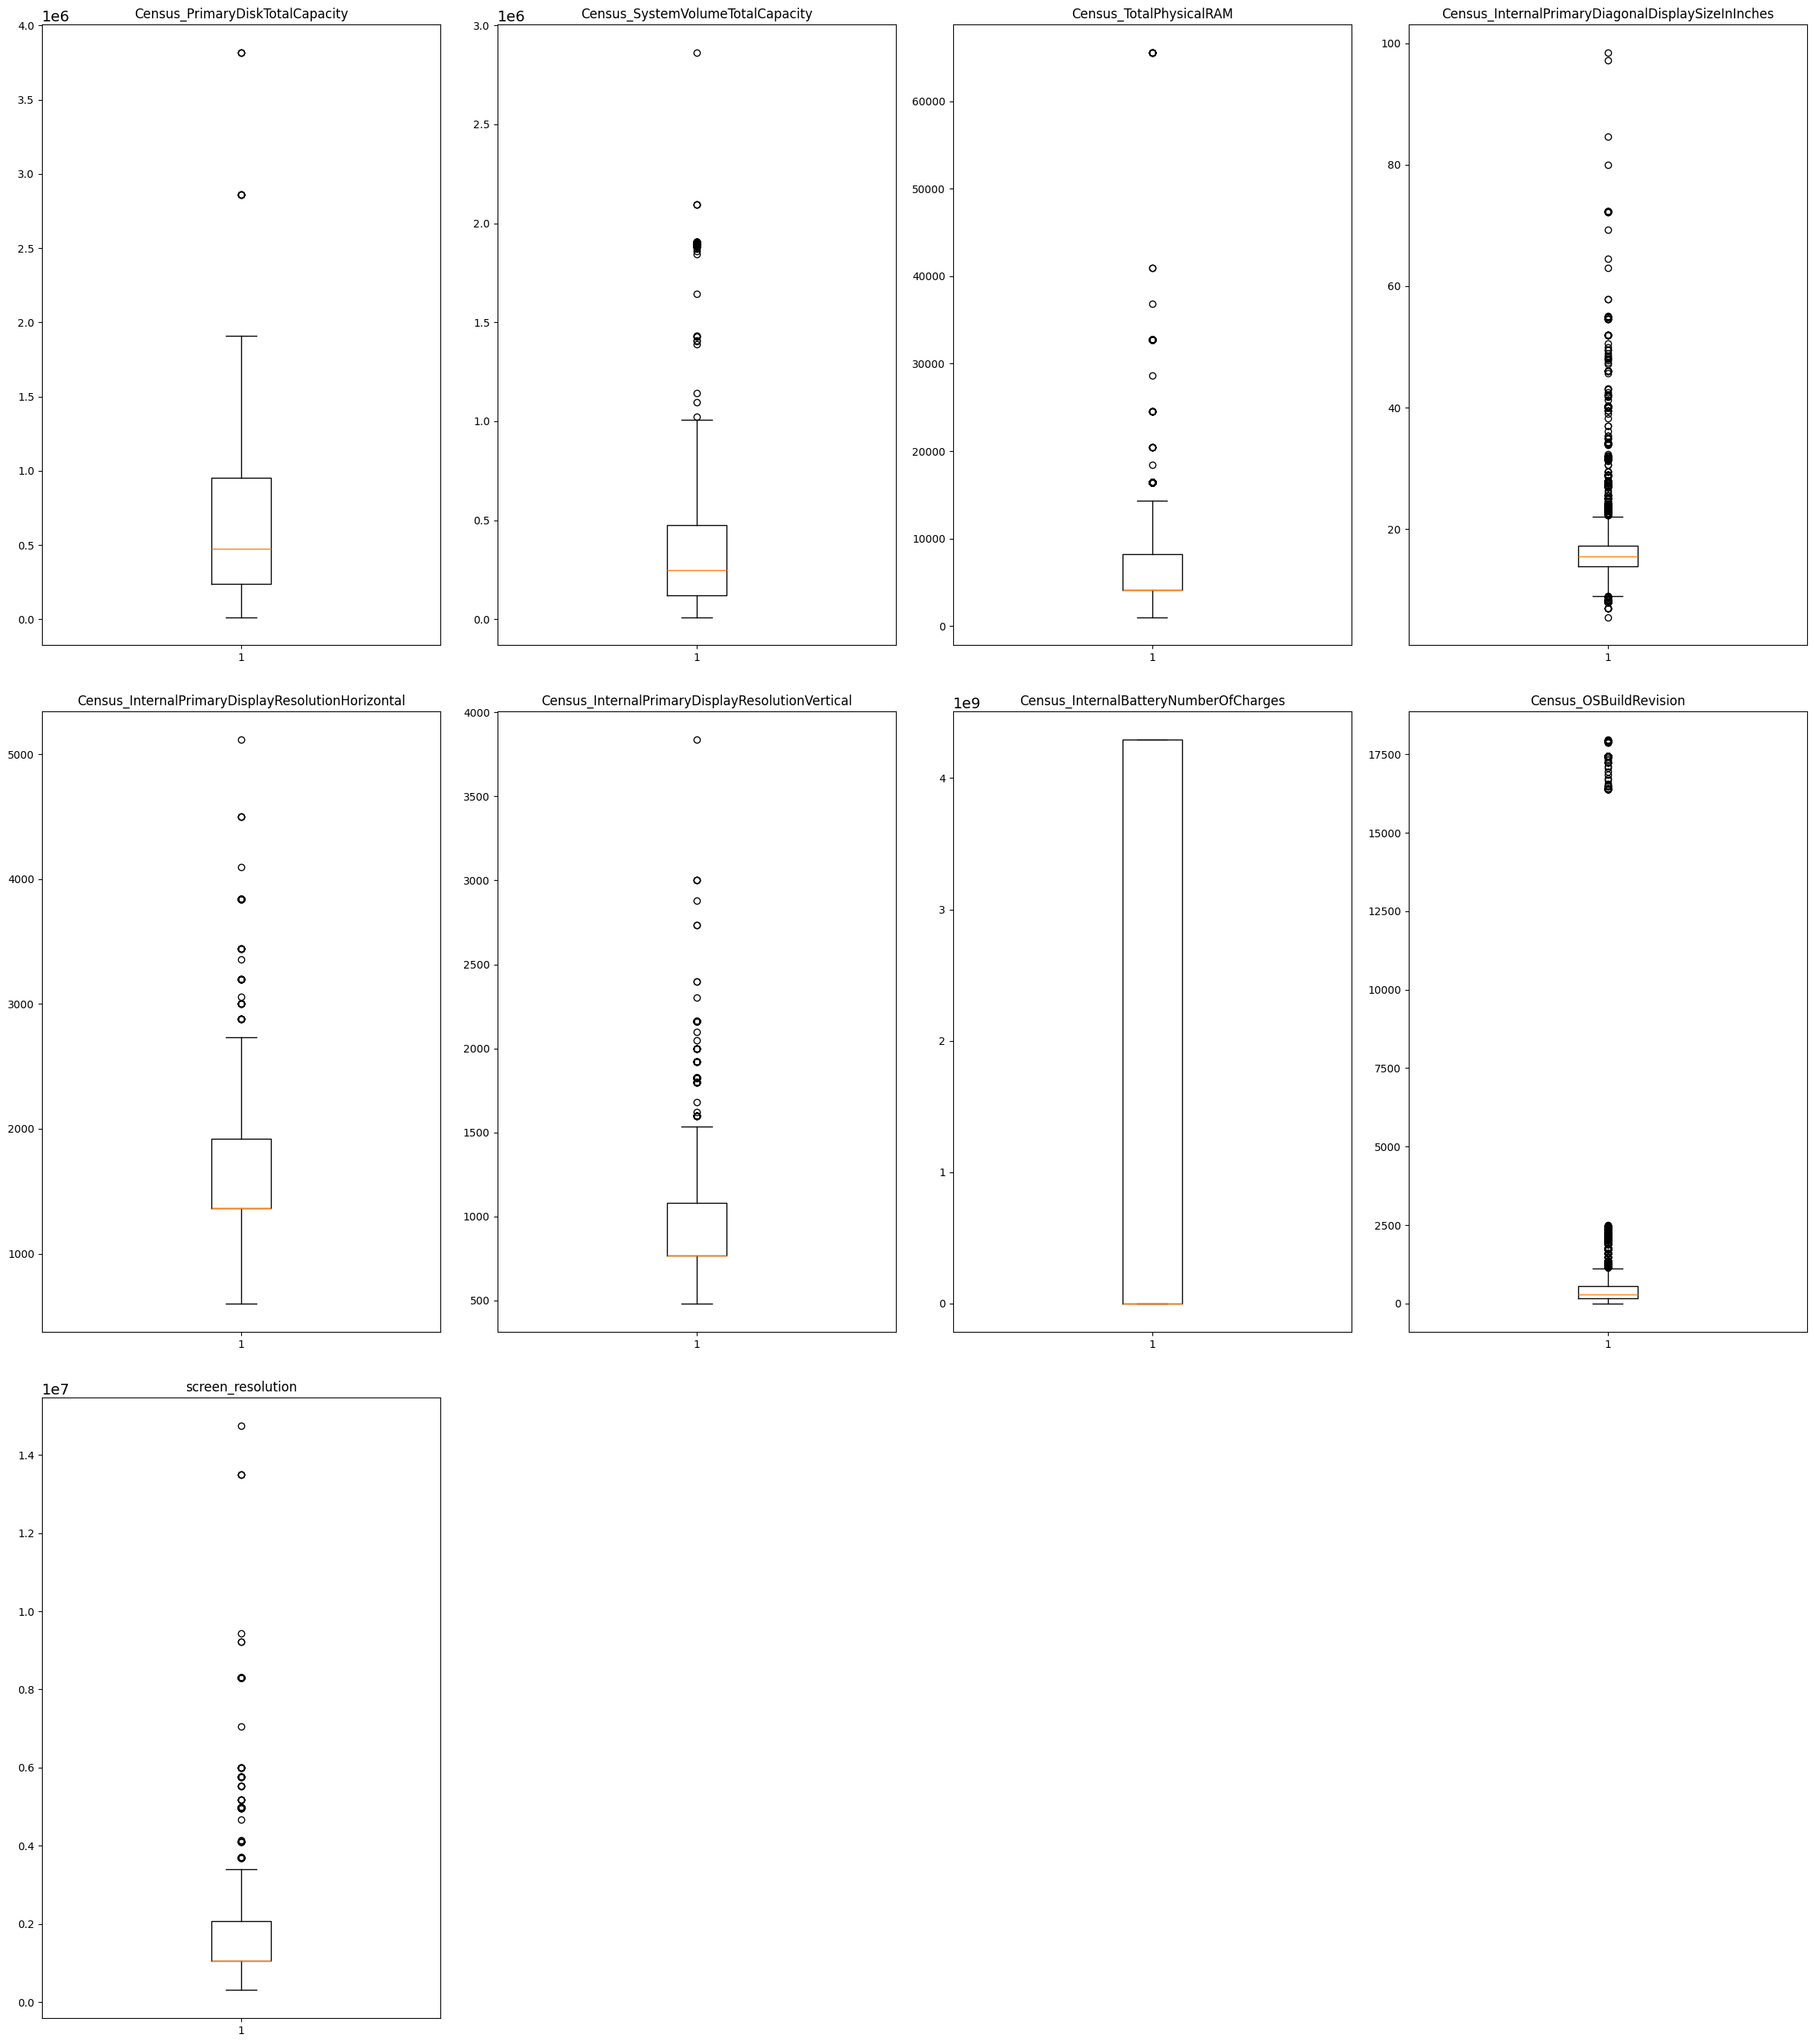

In [104]:
plt.rcParams['font.size'] = 14  # tamaño global de letra

sample = X_train.sample(10000, random_state=42)

fig, axes = plt.subplots(nrows=len(inspector1.numeric_cols)//4 + 1, ncols=4, figsize=(24, len(inspector1.numeric_cols)*3))
axes = axes.flatten()

for i, col in enumerate(inspector1.numeric_cols):
    axes[i].boxplot(sample[col].dropna())
    axes[i].set_title(col, fontsize=12)
    axes[i].tick_params(axis='both', labelsize=10)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

### 4.2. Matriz de correlación

En la matriz podemos observar que destaca la variable AVProductsInstalled por tener una correlación negativa respecto al target. En teoría tener antivirus debería ayudar no? No es lo que se observa en la tabla.

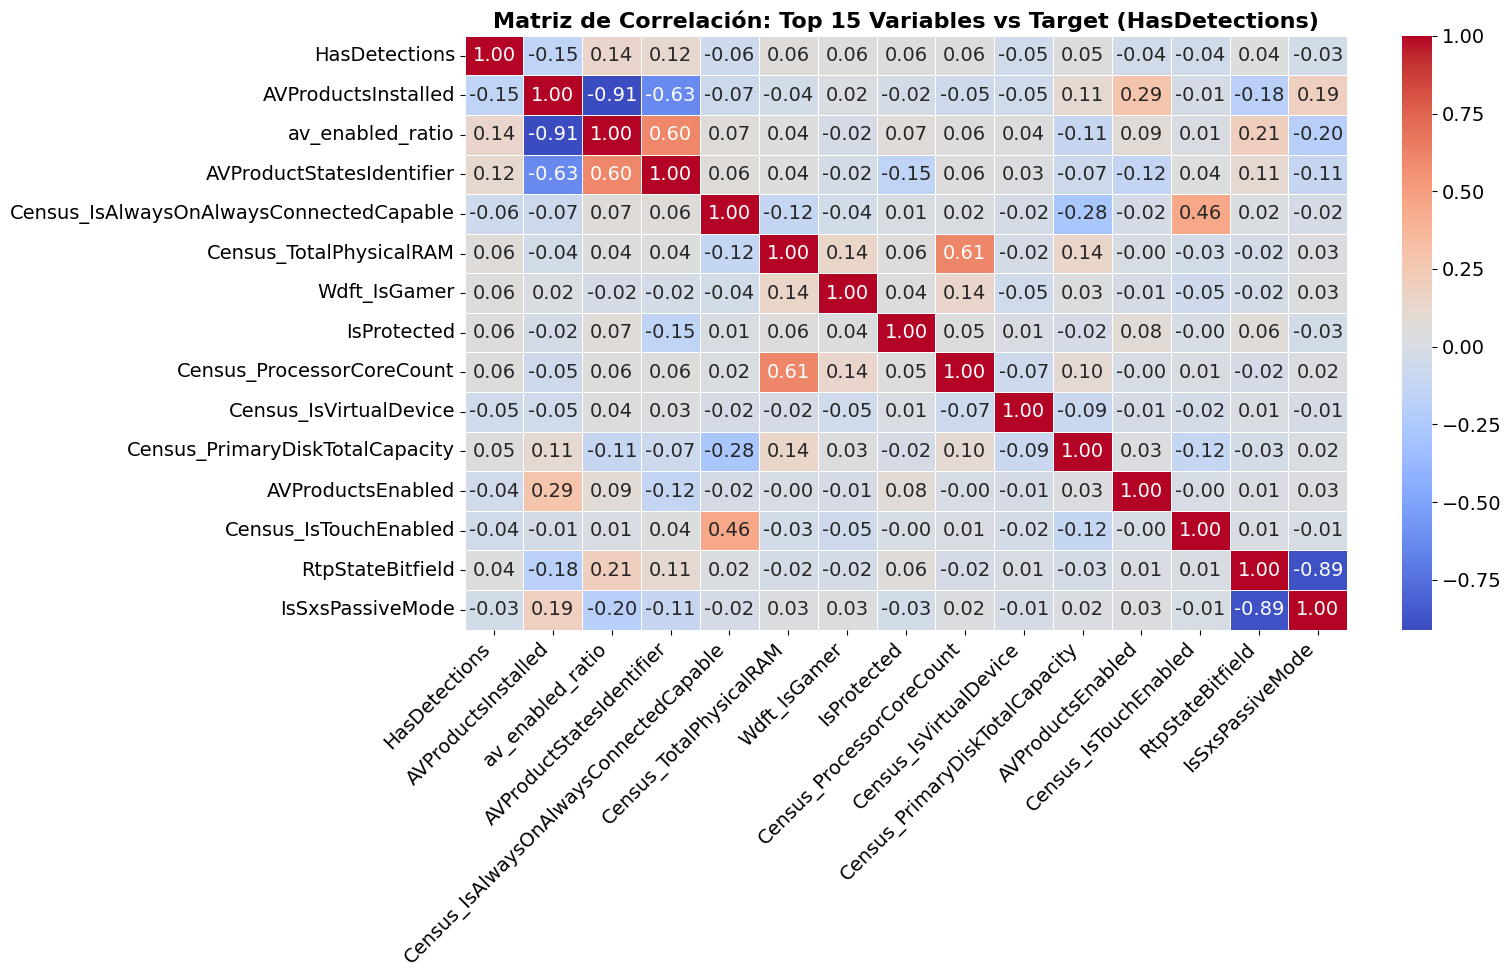


--- TOP 5 VARIABLES MÁS CORRELACIONADAS CON INFECCIONES ---
AVProductsInstalled                       -0.148761
av_enabled_ratio                           0.138260
AVProductStatesIdentifier                  0.116163
Census_IsAlwaysOnAlwaysConnectedCapable   -0.063120
Census_TotalPhysicalRAM                    0.060432
Name: HasDetections, dtype: float64


In [106]:
# Calculamos la correlación de Pearson de todas las variables con 'HasDetections'
# Usamos numeric_only=True por si queda alguna variable no numérica oculta
correlaciones = df.corr(numeric_only=True)['HasDetections']

# Cogemos el valor absoluto para encontrar las relaciones más fuertes 
# (tanto positivas como negativas) y seleccionamos el Top 15 (incluyendo el target)
top_variables_corr = correlaciones.abs().sort_values(ascending=False).head(15).index

# Extraemos solo esas columnas para el gráfico
df_top_corr = df[top_variables_corr]

# Generamos el Mapa de Calor (Heatmap)
plt.figure(figsize=(16, 10))
# cmap='coolwarm' pone colores azules para correlación negativa y rojos para positiva
sns.heatmap(df_top_corr.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Matriz de Correlación: Top 15 Variables vs Target (HasDetections)', fontsize=16, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Mostramos también en texto las 5 variables con mayor impacto directo
print("\n--- TOP 5 VARIABLES MÁS CORRELACIONADAS CON INFECCIONES ---")
print(correlaciones.loc[top_variables_corr[1:6]]) # Saltamos el índice 0 porque es el propio Target

## 5. Pipelines de preprocesado

### 5.1. Creación de clases transformadoras para los Pipelines

- Transformador de tipo de variables a string para su procesado en los pipelines de categóricas. Al tener muchas columnas numéricas con características categóricas, se decide tratarlas como categóricas y esta función permite pasar el tipo de columna a 'str' para que el SimpleImputer pueda añadir la categoría 'missing'. Esta estrategia se basa en la buena gestión de categorías missing por parte de los modelos que se van a desarrollar (dt, rf, lightgbm).

- Transformador RareCategoryGrouper prepara las columnas consideradas de baja cardinalidad para reducir el impacto del One Hot Encoder posterior en la pipeline de baja cardinalidad.

- Transformador FrequencyEncoder: transforma las las columnas consideradas de alta cardinalidad mediante la técnica de etiquetado por frecuencia (de emplear OHE tendríamos demasiadas columnas).

In [ ]:
class ToStringTransformer(BaseEstimator, TransformerMixin):

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        if isinstance(X, pd.DataFrame):
            return X.astype(str)
        else:
            return pd.DataFrame(X).astype(str)

    def get_feature_names_out(self, input_features=None):
        return input_features

In [ ]:
class RareCategoryGrouper(BaseEstimator, TransformerMixin):
    
    def __init__(self, min_freq=0.01):
        self.min_freq = min_freq
    
    def fit(self, X, y=None):
        self.frequent_categories_ = {}

        if not isinstance(X, pd.DataFrame):
            X = pd.DataFrame(X)

        X = X.astype(str).copy()
        
        for col in X.columns:
            freq = X[col].value_counts(normalize=True)
            self.frequent_categories_[col] = set(freq[freq >= self.min_freq].index)
        
        return self
    
    def transform(self, X):
        # Preserve column names if DataFrame, else assign generic
        if isinstance(X, pd.DataFrame):
            X_trans = X.copy()
            cols = X.columns
        else:
            X_trans = pd.DataFrame(X.copy())
            cols = X_trans.columns  # 0..n-1

        for col in cols:
            frequent = self.frequent_categories_.get(col)
            if frequent is None:
                continue  # skip columns not fitted
            X_trans[col] = X_trans[col].astype(str).where(
                X_trans[col].astype(str).isin(frequent),
                "Other"
            )

        return X_trans
    
    def get_feature_names_out(self, input_features=None):
        return input_features
    
class FrequencyEncoder(BaseEstimator, TransformerMixin):
    def __init__(self):
        pass

    def fit(self, X, y=None):
        self.freq_maps_ = {}
        if not isinstance(X, pd.DataFrame):
            X = pd.DataFrame(X)
        for col in X.columns:
            freq = X[col].value_counts(normalize=True)
            self.freq_maps_[col] = freq
        return self

    def transform(self, X):
        if not isinstance(X, pd.DataFrame):
            X_trans = pd.DataFrame(X.copy())
    
        else:
            X_trans = X.copy()

        for col in X_trans.columns:
            freq_map = self.freq_maps_.get(col)
            if freq_map is None:
                continue  # skip columns not fitted
            X_trans[col] = X_trans[col].map(freq_map).fillna(0)
        return X_trans
    
    def get_feature_names_out(self, input_features=None):
        return input_features

### 5.2. Clasificación de las columnas obtenida en el análisis

In [62]:
# Then extract the column lists
numeric_cols = list(inspector1.numeric_cols)
categorical_cols = list(inspector1.object_cols) + list(inspector1.category_cols)
categorical_cols.remove(target)

high_cardinality_cols = list(inspector1.high_cardinality_cols)
low_cardinality_cols = list(set(categorical_cols) - set(high_cardinality_cols))

### 5.3. Definición de las Pipelines de preprocesamiento

- Se ha estado trabajando para poder hacer una separación entre las columnas para hacer diferentes imputaciones en una "impute_pipe" y otra diferente para una "transform_pipe". 

- Sin embargo, dado que se realizarían diferentes clasificaciones de columnas y dado el riesgo de que pudiera aparecer el mismo nombre de columna en dos procesos de la pipeline diferentes, se ha decidido preservar la asignación por grupos de la pipeline de transformación de numérico, categorica de baja cardinalidad y categorica de alta cardinalidad. 

- De esta forma, se ha decidido reducir la complicación de la asignación de nulos: numérica --> mediana y categórica --> 'missing'. 

In [63]:
numeric_pipeline = ColumnTransformer([
    ("median", SimpleImputer(strategy="median"), numeric_cols)
])

In [64]:
low_cardinality_pipeline = Pipeline([
    
    ("to_string", ToStringTransformer()),

    ("imputer", SimpleImputer(strategy="constant", fill_value="Missing")),
    
    ("rare_grouper", RareCategoryGrouper(min_freq=0.01)),
    
    ("OHE", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

In [65]:
high_cardinality_pipeline = Pipeline([
    
    ("to_string", ToStringTransformer()),

    ("imputer", SimpleImputer(strategy="constant", fill_value="Missing")),
    
    ("freq_encoder", FrequencyEncoder())
])

In [66]:
preprocessor = ColumnTransformer(
    transformers = [
    
        ("num", numeric_pipeline, numeric_cols),

        ("low_cat", low_cardinality_pipeline, low_cardinality_cols),
        
        ("high_cat", high_cardinality_pipeline, high_cardinality_cols)
    ],
    remainder="drop",
    n_jobs=1

)

## 6. Modelo DecisionTree

### 6.1. Primer entrenamiento del modelo DecisionTree

In [68]:
DecisionTree_pipe = Pipeline([

    ("preprocessing", preprocessor),

    ("model", DecisionTreeClassifier(
        max_depth=10,     # prevent overfitting
        random_state=42
    ))
])

In [69]:
DecisionTree_pipe.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('low_cat', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different trans

### 6.2. Análisis primer modelo

- Los valores obtenidos de precisión, F1 y F2 scores en el primer modelo son buenos, pero no suficientes dada la estrategia de negocio que implicaría más importancia en los falsos negativos que en los positivos.

- Top 5 features obtenidas son: low_cat__SmartScreen_ExistsNotSet, high_cat__AVProductStatesIdentifier, num__median__Census_PrimaryDiskTotalCapacity, low_cat__EngineVersion_1.1.15100.1 y low_cat__Wdft_IsGamer_1.0.

=== Decision Tree — Test ===

Accuracy : 0.6222
F1 Score : 0.6418
F2 Score : 0.6625

Verdaderos Negativos  (TN): 21,275
Falsos Positivos      (FP): 16,232
Escapes               (FN): 12,106
Virus Cazados         (TP): 25,387


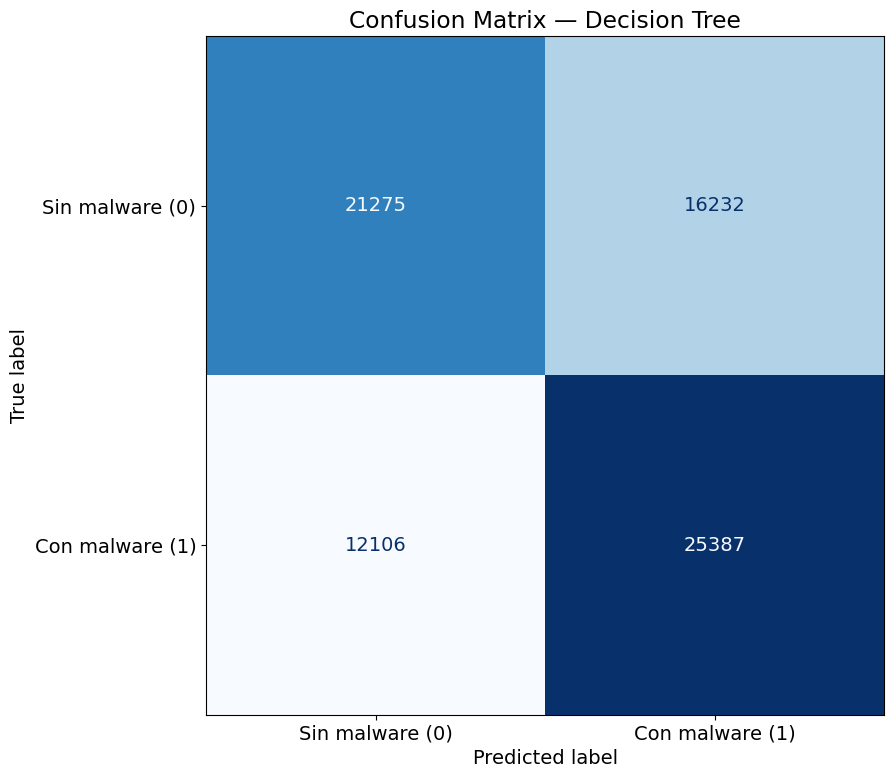

In [109]:
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, fbeta_score, ConfusionMatrixDisplay

y_pred = DecisionTree_pipe.predict(X_test)

acc_dt = accuracy_score(y_test, y_pred)
f1_dt  = f1_score(y_test, y_pred)
f2_dt = fbeta_score(y_test, y_pred, beta=2) # Beta=2 para darle más peso a los falsos negativos
cm_dt  = confusion_matrix(y_test, y_pred)


print("=== Decision Tree — Test ===\n")
print(f"Accuracy : {acc_dt:.4f}")
print(f"F1 Score : {f1_dt:.4f}")
print(f"F2 Score : {f2_dt:.4f}")

print(f"\nVerdaderos Negativos  (TN): {cm_dt[0,0]:,}")
print(f"Falsos Positivos      (FP): {cm_dt[0,1]:,}")
print(f"Escapes               (FN): {cm_dt[1,0]:,}")
print(f"Virus Cazados         (TP): {cm_dt[1,1]:,}")

fig, ax = plt.subplots(figsize=(14, 8))
ConfusionMatrixDisplay(confusion_matrix=cm_dt, display_labels=['Sin malware (0)', 'Con malware (1)']).plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix — Decision Tree')
plt.tight_layout()
plt.show()


=== Top 20 features — Decision Tree ===

                                                       feature  importance
                             low_cat__SmartScreen_ExistsNotSet    0.381907
                           high_cat__AVProductStatesIdentifier    0.226544
                  num__median__Census_PrimaryDiskTotalCapacity    0.056681
                            low_cat__EngineVersion_1.1.15100.1    0.034063
                                     low_cat__Wdft_IsGamer_1.0    0.032513
num__median__Census_InternalPrimaryDiagonalDisplaySizeInInches    0.015303
                          num__median__Census_TotalPhysicalRAM    0.014385
                           low_cat__AppVersion_4.18.1807.18075    0.013682
                                   high_cat__CountryIdentifier    0.013127
                  low_cat__Census_OSInstallTypeName_UUPUpgrade    0.010672
                     high_cat__Census_ProcessorModelIdentifier    0.009426
                      low_cat__Census_OSUILocaleIdentifier_

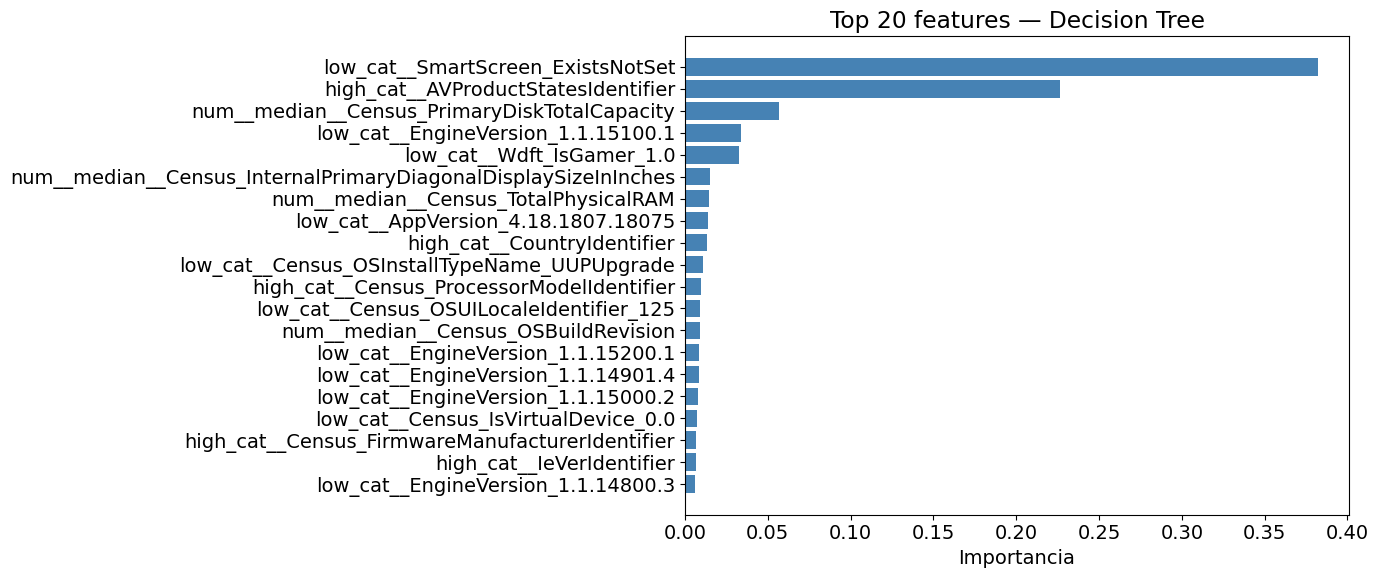

In [71]:

# Feature importance del Decision Tree tuneado
# Con OHE, los nombres de columnas los obtenemos del preprocessor
X_train_trans = DecisionTree_pipe.named_steps["preprocessing"].transform(X_train)
feature_names_dt = X_train_trans.columns.tolist()

fi_dt = pd.Series(
    DecisionTree_pipe.named_steps["model"].feature_importances_,
    index=feature_names_dt
).sort_values(ascending=False)
fi_dt_df = fi_dt.reset_index()
fi_dt_df.columns = ['feature', 'importance']

print("=== Top 20 features — Decision Tree ===\n")
print(fi_dt_df.head(20).to_string(index=False))

# Plot
top_n = 20
fi_dt_top = fi_dt_df.head(top_n)

fig, ax = plt.subplots(figsize=(14, 6))
ax.barh(fi_dt_top['feature'][::-1], fi_dt_top['importance'][::-1], color='steelblue')
ax.set_xlabel('Importancia')
ax.set_title(f'Top {top_n} features — Decision Tree')
plt.tight_layout()
plt.show()


#### 6.2.1. Gráfica del efecto del cambio de threshold

- Con esta gráfica y la posterior tabla, se van a analizar los resultados de los modelos, así como la influencia del threshold en la precisión y scoring del modelo. 

- El threshold determina la probabilidad a partir de la cuál el modelo predecirá si la máquina tiene malware. Se puede emplear como tuning de cara a mejorar la detección.

In [72]:
y_prob = DecisionTree_pipe.predict_proba(X_test)[:,1]

In [73]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

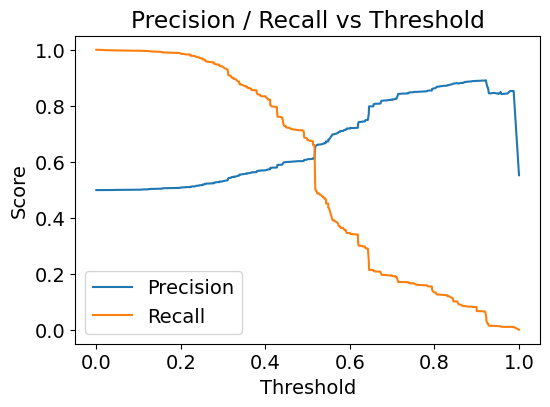

In [74]:
plt.figure(figsize=(6,4))
plt.plot(thresholds, precision[:-1], label="Precision")
plt.plot(thresholds, recall[:-1], label="Recall")

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision / Recall vs Threshold")
plt.legend()
plt.show()

In [110]:
# Ajuste del umbral de clasificacion para reducir FN
# Criterio: minimizar FN (prioridad de negocio en detección de malware)
y_proba_dt = DecisionTree_pipe.predict_proba(X_test)[:, 1]

print(f"{'Threshold':<12} {'Accuracy':>10} {'F1':>10} {'F2':>10} {'FN':>10} {'FP':>10}")
print("-" * 68)

for threshold in [0.6, 0.55, 0.5, 0.45, 0.4, 0.35, 0.3, 0.25]:
    y_pred_t = (y_proba_dt >= threshold).astype(int)
    cm_t = confusion_matrix(y_test, y_pred_t)
    f1_t = f1_score(y_test, y_pred_t)
    f2_dt = fbeta_score(y_test, y_pred_t, beta=2)
    print(f"{threshold:<12} {accuracy_score(y_test, y_pred_t):>10.4f} {f1_t:>10.4f} {f2_dt:>10.4f} {cm_t[1,0]:>10,} {cm_t[0,1]:>10,}")

# Threshold elegido: 0.35 — minimiza FN (dispositivos infectados no detectados)
# En seguridad, un FN es más costoso que un FP
best_threshold_dt = 0.35
print(f"\nThreshold seleccionado: {best_threshold_dt} (criterio: minimizar FN)")

Threshold      Accuracy         F1         F2         FN         FP
--------------------------------------------------------------------
0.6              0.6057     0.4676     0.3865     24,505      5,070
0.55             0.6153     0.5307     0.4689     21,181      7,672
0.5              0.6222     0.6419     0.6628     12,094     16,242
0.45             0.6207     0.6556     0.6939     10,418     18,033
0.4              0.6027     0.6773     0.7634      6,224     23,571
0.35             0.5905     0.6799     0.7825      4,876     25,835
0.3              0.5563     0.6787     0.8134      2,347     30,930
0.25             0.5338     0.6750     0.8250      1,182     33,786

Threshold seleccionado: 0.35 (criterio: minimizar FN)


### 6.3. Tuning de hiperparámetros — Decision Tree

#### 6.3.1. Detección de columnas con baja importancia

En vistas a mejorar los siguientes modelos, se realiza un agrupamiento (por las columnas procedentes del OHE) de features con su importancia correspondiente para poder eliminar aquella columnas con baja o nula utilización.

In [ ]:
least_used_features = fi_dt[fi_dt == 0].index.tolist()

print(f"Número de columnas sin utilizar: {len(least_used_features)}")

Number of unused features: 100


In [80]:
def get_zero_importance_features(model, preprocessor):

    feature_names = preprocessor.get_feature_names_out()
    importances = model.feature_importances_

    df = pd.DataFrame({
        "feature": feature_names,
        "importance": importances
    })

    df["original_feature"] = (
        df["feature"]
        .str.split("__").str[-1]
        .str.split("_").str[0]
    )

    grouped = df.groupby("original_feature")["importance"].sum()

    return grouped[grouped < 0.0004].index.tolist()

In [81]:
droppable_past1st_model = get_zero_importance_features(DecisionTree_pipe.named_steps["model"], DecisionTree_pipe.named_steps["preprocessing"])
print(f"{len(droppable_past1st_model)} Features con baja influenciaen el Decision Tree: {droppable_past1st_model}")


9 Features con baja influenciaen el Decision Tree: ['AVProductsEnabled', 'HasTpm', 'IsBeta', 'OsSuite', 'OsVer', 'ProductName', 'SkuEdition', 'UacLuaenable', 'app']


In [82]:
inspector1.apply_drops(droppable_past1st_model)

Dropped 8 columns: ['ProductName', 'UacLuaenable', 'HasTpm', 'SkuEdition', 'IsBeta', 'AVProductsEnabled', 'OsSuite', 'OsVer']


In [83]:
# Then extract the column lists
numeric_cols2 = list(inspector1.numeric_cols)
categorical_cols2 = list(inspector1.object_cols) + list(inspector1.category_cols)
categorical_cols2.remove(target)

high_cardinality_cols2 = list(inspector1.high_cardinality_cols)
low_cardinality_cols2 = list(set(categorical_cols2) - set(high_cardinality_cols2))

A partir de ahora se empleará el preprocessor2 para los modelos

In [84]:
preprocessor2 = ColumnTransformer(
    transformers = [
    
        ("num", numeric_pipeline, numeric_cols2),

        ("low_cat", low_cardinality_pipeline, low_cardinality_cols2),
        
        ("high_cat", high_cardinality_pipeline, high_cardinality_cols2)
    ],
    remainder="drop",
    n_jobs=1

)

#### 6.3.2. RandomizedSearchCV

Tras una serie de iteraciones se han cambiado los diferentes parámetros y el scoring para buscar la solución óptima mediante este optimizador. La mejor opción entre los scoring empleados ha resultado ser 'roc_auc'. 'recall' producía modelos centrados en pocas variables y con baja precisión. 'f1' mejoraba los resultados de 'recall', pero los resultados con top_features más escalonados y con mejor precisión se han obtenido con 'roc_auc'.

In [85]:
from sklearn.model_selection import RandomizedSearchCV

# Submuestra para acelerar el tuning
sample_idx_dt = np.random.RandomState(42).choice(len(X_train), size=50_000, replace=False)
X_tune_dt = X_train.iloc[sample_idx_dt]
y_tune_dt  = y_train.iloc[sample_idx_dt]

param_dist_dt = {
    'model__criterion'        : ['gini', 'entropy'],
    'model__max_depth'        : [5, 10, 20, None],
    'model__min_samples_split': [20, 30, 40, 50],
    'model__min_samples_leaf' : [20, 30, 40, 50],
    'model__max_features'     : [None, 'sqrt', 'log2'],
    'model__class_weight'     : ['balanced', None],
    'model__ccp_alpha'        : [0.0, 1e-4, 1e-3, 1e-2],
}

basic_dt_pipe = Pipeline([
    ("preprocessing", preprocessor2),
    ("model", DecisionTreeClassifier(random_state=42))
])

dt_search = RandomizedSearchCV(
    estimator           = basic_dt_pipe,
    param_distributions = param_dist_dt,
    n_iter              = 30,
    scoring             = 'roc_auc',
    cv                  = 3,
    random_state        = 42,
    n_jobs              = -1,
    verbose             = 1,
)
dt_search.fit(X_tune_dt, y_tune_dt)

print(f"Mejores parámetros: {dt_search.best_params_}")
print(f"Mejor F1 (CV):      {dt_search.best_score_:.4f}")

# Tuning del Decision Tree sobre datos que ya incluyen las 3 features de FE:
# av_enabled_ratio, screen_resolution, app_version_major.
# Se usa una submuestra de 50k filas para reducir el tiempo de búsqueda
# manteniendo representatividad (≈15% del train).

Fitting 3 folds for each of 30 candidates, totalling 90 fits
Mejores parámetros: {'model__min_samples_split': 50, 'model__min_samples_leaf': 50, 'model__max_features': None, 'model__max_depth': 10, 'model__criterion': 'gini', 'model__class_weight': None, 'model__ccp_alpha': 0.0001}
Mejor F1 (CV):      0.6685


In [86]:
# Reentrenamos con los mejores parámetros sobre todo el train transformado
best_dt_pipe = dt_search.best_estimator_

y_pred_best_dt = best_dt_pipe.predict(X_test)

acc_dt_tuned = accuracy_score(y_test, y_pred_best_dt)
f1_dt_tuned  = f1_score(y_test, y_pred_best_dt)
f2_dt_tuned  = fbeta_score(y_test, y_pred_best_dt, beta=2)
cm_dt_tuned  = confusion_matrix(y_test, y_pred_best_dt)

thresholds = np.linspace(0, 1, 101)
probs = best_dt_pipe.predict_proba(X_test)[:, 1]

f1_scores = [f1_score(y_test, probs > t) for t in thresholds]
f2_scores = [fbeta_score(y_test, probs > t, beta=2) for t in thresholds]

best_f1_idx = np.argmax(f1_scores)
best_f2_idx = np.argmax(f2_scores)

best_threshold_f1 = thresholds[best_f1_idx]
best_threshold_f2 = thresholds[best_f2_idx]

print("Best F1 threshold:", best_threshold_f1)
print("Best F2 threshold:", best_threshold_f2)

print("=== Decision Tree Tuneado - Validacion ===")
print()
print(f"Accuracy : {acc_dt_tuned:.4f}")
print(f"F1 Score : {f1_dt_tuned:.4f}")
print(f"F2 Score : {f2_dt_tuned:.4f}")
print(f"\nVerdaderos Negativos  (TN): {cm_dt_tuned[0,0]:,}")
print(f"Falsos Positivos      (FP): {cm_dt_tuned[0,1]:,}")
print(f"Falsos Negativos      (FN): {cm_dt_tuned[1,0]:,}")
print(f"Verdaderos Positivos  (TP): {cm_dt_tuned[1,1]:,}")

Best F1 threshold: 0.32
Best F2 threshold: 0.13
=== Decision Tree Tuneado - Validacion ===

Accuracy : 0.6158
F1 Score : 0.6310
F2 Score : 0.6465

Verdaderos Negativos  (TN): 21,542
Falsos Positivos      (FP): 15,965
Falsos Negativos      (FN): 12,853
Verdaderos Positivos  (TP): 24,640


=== Top 20 features — Decision Tree ===

                                                       feature  importance
                             low_cat__SmartScreen_ExistsNotSet    0.432681
                           high_cat__AVProductStatesIdentifier    0.204573
                  num__median__Census_PrimaryDiskTotalCapacity    0.062808
                                     low_cat__Wdft_IsGamer_1.0    0.035853
                            low_cat__EngineVersion_1.1.15100.1    0.034646
                            low_cat__EngineVersion_1.1.14901.4    0.013087
                            low_cat__EngineVersion_1.1.15000.2    0.012661
                           low_cat__AppVersion_4.18.1807.18075    0.012017
num__median__Census_InternalPrimaryDiagonalDisplaySizeInInches    0.011348
                     high_cat__Census_ProcessorModelIdentifier    0.010305
                              low_cat__AVProductsInstalled_3.0    0.010221
                           num__median__Census_OSBuildRevis

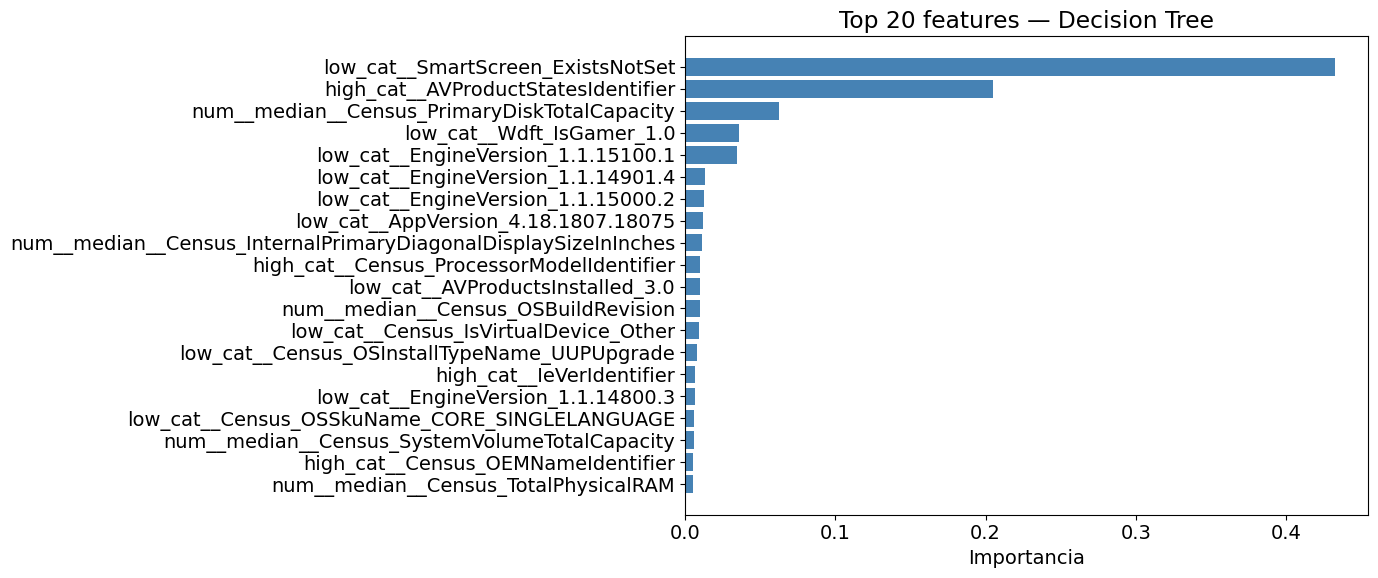

In [87]:

# Feature importance del Decision Tree tuneado
# Con OHE, los nombres de columnas los obtenemos del preprocessor
X_train_trans = best_dt_pipe.named_steps["preprocessing"].transform(X_train)
feature_names_dt = X_train_trans.columns.tolist()

fi_best_dt = pd.Series(
    best_dt_pipe.named_steps["model"].feature_importances_,
    index=feature_names_dt
).sort_values(ascending=False)
fi_best_dt_df = fi_best_dt.reset_index()
fi_best_dt_df.columns = ['feature', 'importance']

print("=== Top 20 features — Decision Tree ===\n")
print(fi_best_dt_df.head(20).to_string(index=False))

# Plot
top_n = 20
fi_best_dt_top = fi_best_dt_df.head(top_n)

fig, ax = plt.subplots(figsize=(14, 6))
ax.barh(fi_best_dt_top['feature'][::-1], fi_best_dt_top['importance'][::-1], color='steelblue')
ax.set_xlabel('Importancia')
ax.set_title(f'Top {top_n} features — Decision Tree')
plt.tight_layout()
plt.show()


In [118]:
# Ajuste del umbral de clasificacion para reducir FN
# Criterio: minimizar FN (prioridad de negocio en detección de malware)
y_proba_best_dt = best_dt_pipe.predict_proba(X_test)[:, 1]

print(f"{'Threshold':<12} {'Accuracy':>10} {'F1':>10} {'F2':>10} {'FN':>10} {'FP':>10}")
print("-" * 68)

for threshold in [0.6, 0.55, 0.5, 0.45, 0.4, 0.35, 0.3, 0.25]:
    y_pred_t = (y_proba_best_dt >= threshold).astype(int)
    cm_t = confusion_matrix(y_test, y_pred_t)
    f1_t = f1_score(y_test, y_pred_t)
    f2_dt = fbeta_score(y_test, y_pred_t, beta=2)
    print(f"{threshold:<12} {accuracy_score(y_test, y_pred_t):>10.4f} {f1_t:>10.4f} {f2_dt:>10.4f} {cm_t[1,0]:>10,} {cm_t[0,1]:>10,}")

# Threshold elegido: 0.4 — minimiza FN (dispositivos infectados no detectados)
# En seguridad, un FN es más costoso que un FP
best_threshold_dt = 0.4
print(f"\nThreshold seleccionado: {best_threshold_dt} (criterio: minimizar FN)")

Threshold      Accuracy         F1         F2         FN         FP
--------------------------------------------------------------------
0.6              0.5985     0.4453     0.3624     25,405      4,708
0.55             0.6168     0.5472     0.4935     20,128      8,611
0.5              0.6158     0.6310     0.6465     12,853     15,965
0.45             0.6136     0.6530     0.6956     10,225     18,755
0.4              0.5938     0.6702     0.7556      6,535     23,931
0.35             0.5881     0.6753     0.7738      5,360     25,536
0.3              0.5371     0.6726     0.8159      1,837     32,877
0.25             0.5302     0.6722     0.8211      1,374     33,860

Threshold seleccionado: 0.4 (criterio: minimizar FN)


#### 6.3.3. Grid

En este apartado se ha probado a realizar el optimizador anterior pero con todo el dataset. Tarda más al emplear todo el dataset, pero se puede observar una ligera mejora.

In [ ]:
grid_param_dist_dt = {
    'model__criterion'        : ['gini', 'entropy'],
    'model__max_depth'        : [5, 10, 20, None],
    'model__min_samples_split': [20, 30, 40, 50],
    'model__min_samples_leaf' : [20, 30, 40, 50],
    'model__max_features'     : [None, 'sqrt', 'log2'],
    'model__class_weight'     : ['balanced', None],
    'model__ccp_alpha'        : [0.0, 1e-4, 1e-3, 1e-2],
}

grid_param_dist_dtbasic_dt_pipe = Pipeline([
    ("preprocessing", preprocessor2),
    ("model", DecisionTreeClassifier(random_state=42))
])

grid_dt_search = RandomizedSearchCV(
    estimator           = grid_param_dist_dtbasic_dt_pipe,
    param_distributions = grid_param_dist_dt,
    n_iter              = 30,
    scoring             = 'roc_auc',
    cv                  = 3,
    random_state        = 42,
    n_jobs              = -1,
    verbose             = 1,
)
grid_dt_search.fit(X_train, y_train)

print(f"Mejores parámetros: {grid_dt_search.best_params_}")
print(f"Mejor F1 (CV):      {grid_dt_search.best_score_:.4f}")

# Tuning del Decision Tree sobre datos que ya incluyen las 3 features de FE:
# av_enabled_ratio, screen_resolution, app_version_major.
# Se usa una submuestra de 50k filas para reducir el tiempo de búsqueda
# manteniendo representatividad (≈15% del train).

Fitting 3 folds for each of 30 candidates, totalling 90 fits
Mejores parámetros: {'model__min_samples_split': 50, 'model__min_samples_leaf': 50, 'model__max_features': None, 'model__max_depth': 10, 'model__criterion': 'gini', 'model__class_weight': None, 'model__ccp_alpha': 0.0001}
Mejor F1 (CV):      0.6759


In [90]:
# Reentrenamos con los mejores parámetros sobre todo el train transformado
grid_dt_pipe = dt_search.best_estimator_

y_pred_grid_dt = grid_dt_pipe.predict(X_test)

grid_acc_dt_tuned = accuracy_score(y_test, y_pred_grid_dt)
grid_f1_dt_tuned  = f1_score(y_test, y_pred_grid_dt)
grid_f2_dt_tuned  = fbeta_score(y_test, y_pred_grid_dt, beta=2)
grid_cm_dt_tuned  = confusion_matrix(y_test, y_pred_grid_dt)

thresholds = np.linspace(0, 1, 101)
probs = grid_dt_pipe.predict_proba(X_test)[:, 1]

f1_scores = [f1_score(y_test, probs > t) for t in thresholds]
f2_scores = [fbeta_score(y_test, probs > t, beta=2) for t in thresholds]

grid_f1_idx = np.argmax(f1_scores)
grid_f2_idx = np.argmax(f2_scores)

grid_threshold_f1 = thresholds[grid_f1_idx]
grid_threshold_f2 = thresholds[grid_f2_idx]

print("Best F1 threshold:", grid_threshold_f1)
print("Best F2 threshold:", grid_threshold_f2)

print("=== Decision Tree Tuneado - Validacion ===")
print()
print(f"Accuracy : {grid_acc_dt_tuned:.4f}")
print(f"F1 Score : {grid_f1_dt_tuned:.4f}")
print(f"F2 Score : {grid_f2_dt_tuned:.4f}")
print(f"\nVerdaderos Negativos  (TN): {grid_cm_dt_tuned[0,0]:,}")
print(f"Falsos Positivos      (FP): {grid_cm_dt_tuned[0,1]:,}")
print(f"Falsos Negativos      (FN): {grid_cm_dt_tuned[1,0]:,}")
print(f"Verdaderos Positivos  (TP): {grid_cm_dt_tuned[1,1]:,}")

Best F1 threshold: 0.32
Best F2 threshold: 0.13
=== Decision Tree Tuneado - Validacion ===

Accuracy : 0.6158
F1 Score : 0.6310
F2 Score : 0.6465

Verdaderos Negativos  (TN): 21,542
Falsos Positivos      (FP): 15,965
Falsos Negativos      (FN): 12,853
Verdaderos Positivos  (TP): 24,640


=== Top 20 features — Decision Tree ===

                                                       feature  importance
                             low_cat__SmartScreen_ExistsNotSet    0.432681
                           high_cat__AVProductStatesIdentifier    0.204573
                  num__median__Census_PrimaryDiskTotalCapacity    0.062808
                                     low_cat__Wdft_IsGamer_1.0    0.035853
                            low_cat__EngineVersion_1.1.15100.1    0.034646
                            low_cat__EngineVersion_1.1.14901.4    0.013087
                            low_cat__EngineVersion_1.1.15000.2    0.012661
                           low_cat__AppVersion_4.18.1807.18075    0.012017
num__median__Census_InternalPrimaryDiagonalDisplaySizeInInches    0.011348
                     high_cat__Census_ProcessorModelIdentifier    0.010305
                              low_cat__AVProductsInstalled_3.0    0.010221
                           num__median__Census_OSBuildRevis

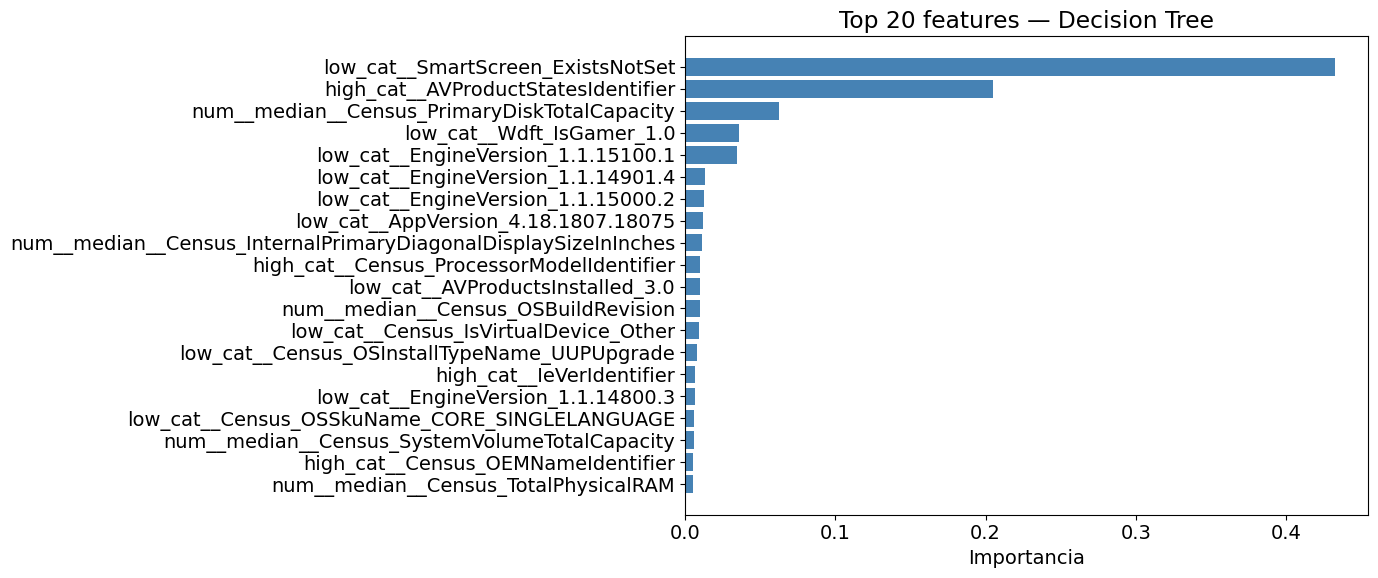

In [111]:

# Feature importance del Decision Tree tuneado
# Con OHE, los nombres de columnas los obtenemos del preprocessor
X_train_trans = best_dt_pipe.named_steps["preprocessing"].transform(X_train)
feature_names_dt = X_train_trans.columns.tolist()

fi_best_dt = pd.Series(
    best_dt_pipe.named_steps["model"].feature_importances_,
    index=feature_names_dt
).sort_values(ascending=False)
fi_best_dt_df = fi_best_dt.reset_index()
fi_best_dt_df.columns = ['feature', 'importance']

print("=== Top 20 features — Decision Tree ===\n")
print(fi_best_dt_df.head(20).to_string(index=False))

# Plot
top_n = 20
fi_best_dt_top = fi_best_dt_df.head(top_n)

fig, ax = plt.subplots(figsize=(14, 6))
ax.barh(fi_best_dt_top['feature'][::-1], fi_best_dt_top['importance'][::-1], color='steelblue')
ax.set_xlabel('Importancia')
ax.set_title(f'Top {top_n} features — Decision Tree')
plt.tight_layout()
plt.show()


In [121]:
# Ajuste del umbral de clasificacion para reducir FN
# Criterio: minimizar FN (prioridad de negocio en detección de malware)
y_proba_best_dt = grid_dt_pipe.predict_proba(X_test)[:, 1]

print(f"{'Threshold':<12} {'Accuracy':>10} {'F1':>10} {'F2':>10} {'FN':>10} {'FP':>10}")
print("-" * 68)

for threshold in [0.6, 0.55, 0.5, 0.45, 0.4, 0.35, 0.3, 0.25]:
    y_pred_t = (y_proba_best_dt >= threshold).astype(int)
    cm_t = confusion_matrix(y_test, y_pred_t)
    f1_t = f1_score(y_test, y_pred_t)
    f2_dt = fbeta_score(y_test, y_pred_t, beta=2)
    print(f"{threshold:<12} {accuracy_score(y_test, y_pred_t):>10.4f} {f1_t:>10.4f} {f2_dt:>10.4f} {cm_t[1,0]:>10,} {cm_t[0,1]:>10,}")

# Threshold elegido: 0.4 — minimiza FN (dispositivos infectados no detectados)
# En seguridad, un FN es más costoso que un FP
best_threshold_dt_grid = 0.4
print(f"\nThreshold seleccionado: {best_threshold_dt_grid} (criterio: minimizar FN)")

Threshold      Accuracy         F1         F2         FN         FP
--------------------------------------------------------------------
0.6              0.5985     0.4453     0.3624     25,405      4,708
0.55             0.6168     0.5472     0.4935     20,128      8,611
0.5              0.6158     0.6310     0.6465     12,853     15,965
0.45             0.6136     0.6530     0.6956     10,225     18,755
0.4              0.5938     0.6702     0.7556      6,535     23,931
0.35             0.5881     0.6753     0.7738      5,360     25,536
0.3              0.5371     0.6726     0.8159      1,837     32,877
0.25             0.5302     0.6722     0.8211      1,374     33,860

Threshold seleccionado: 0.4 (criterio: minimizar FN)


### 6.4. Conclusiones DecisionTree

In [126]:
dt_comparativa_real = []

# A. Dummy (Baseline) - Calculado sobre la marcha
from sklearn.dummy import DummyClassifier
dummy = DummyClassifier(strategy="most_frequent").fit(X_train, y_train)
y_pred_dummy = dummy.predict(X_val)
dt_comparativa_real.append({
    "Modelo": "Dummy (baseline)",
    "Accuracy": accuracy_score(y_val, y_pred_dummy),
    "F1": f1_score(y_val, y_pred_dummy, zero_division=0),
    "FN": "—"
})

# B. DT base (El primero que entrenamos con threshold 0.5)

y_pred_dt_base = DecisionTree_pipe.predict(X_val)
cm_base = confusion_matrix(y_val, y_pred_dt_base)
dt_comparativa_real.append({
    "Modelo": "DT base (threshold=0.5)",
    "Accuracy": accuracy_score(y_val, y_pred_dt_base),
    "F1": f1_score(y_val, y_pred_dt_base),
    "FN": f"{cm_base[1,0]:,}"
})

# C. Best DT (El mejor_dt tras RandomizedSearch con threshold 0.4)
y_prob_tuneado = best_dt_pipe.predict_proba(X_val)[:, 1]
y_pred_tuneado_best_th = (y_prob_tuneado >= best_threshold_dt).astype(int)
cm_tuneado = confusion_matrix(y_val, y_pred_tuneado_best_th)
dt_comparativa_real.append({
    "Modelo": "DT tuneado (threshold=0.4)",
    "Accuracy": accuracy_score(y_val, y_pred_tuneado_best_th),
    "F1": f1_score(y_val, y_pred_tuneado_best_th),
    "FN": f"{cm_tuneado[1,0]:,}"
})

# # D. Best DT con GridSearch (El dt tras GridSearch con threshold 0.4)
# y_prob_tuneado_grid = grid_dt_pipe.predict_proba(X_val)[:, 1]
# y_pred_tuneado_best_th_grid = (y_prob_tuneado_grid >= best_threshold_dt_grid).astype(int)
# cm_tuneado_grid = confusion_matrix(y_val, y_pred_tuneado_best_th_grid)
# dt_comparativa_real.append({
#     "Modelo": "DT grid tuneado (threshold=0.4)",
#     "Accuracy": accuracy_score(y_val, y_pred_tuneado_best_th_grid),
#     "F1": f1_score(y_val, y_pred_tuneado_best_th_grid),
#     "FN": f"{cm_tuneado_grid[1,0]:,}"
# })

# --- IMPRESIÓN DE LA TABLA FORMATEADA ---
print("=== COMPARATIVA DT COMPLETA (VALORES REALES) ===")
print("-" * 75)
print(f"{'Modelo':<35} {'Accuracy':<12} {'F1':<10} {'FN (Escapes)':<15}")
print("-" * 75)

for m in dt_comparativa_real:
    acc_str = f"{m['Accuracy']:.4f}" if isinstance(m['Accuracy'], float) else m['Accuracy']
    f1_str = f"{m['F1']:.4f}" if isinstance(m['F1'], float) else m['F1']
    print(f"{m['Modelo']:<35} {acc_str:<12} {f1_str:<10} {m['FN']:<15}")

print("-" * 75)

=== COMPARATIVA DT COMPLETA (VALORES REALES) ===
---------------------------------------------------------------------------
Modelo                              Accuracy     F1         FN (Escapes)   
---------------------------------------------------------------------------
Dummy (baseline)                    0.5001       0.0000     —              
DT base (threshold=0.5)             0.6216       0.6411     12,141         
DT tuneado (threshold=0.4)          0.5930       0.6689     6,654          
---------------------------------------------------------------------------


## 7. Otros modelos

### 7.1. Random Forest

#### 7.1.1. Primer Modelo RandomForest

In [93]:
Random_Forest_model_pipeline = Pipeline([
    
    ("preprocessing", preprocessor2),
    
    ("model", RandomForestClassifier(
        n_estimators=200,
        max_depth=None,
        n_jobs=-1,
        random_state=42
    ))
])

In [94]:
Random_Forest_model_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('low_cat', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different trans

=== Random Forest — Validación ===

Accuracy : 0.6405
F1 Score : 0.6332
F2 Score : 0.6255

Verdaderos Negativos  (TN): 24,775
Falsos Positivos      (FP): 12,732
Escapes               (FN): 14,227
Virus Cazados         (TP): 23,266


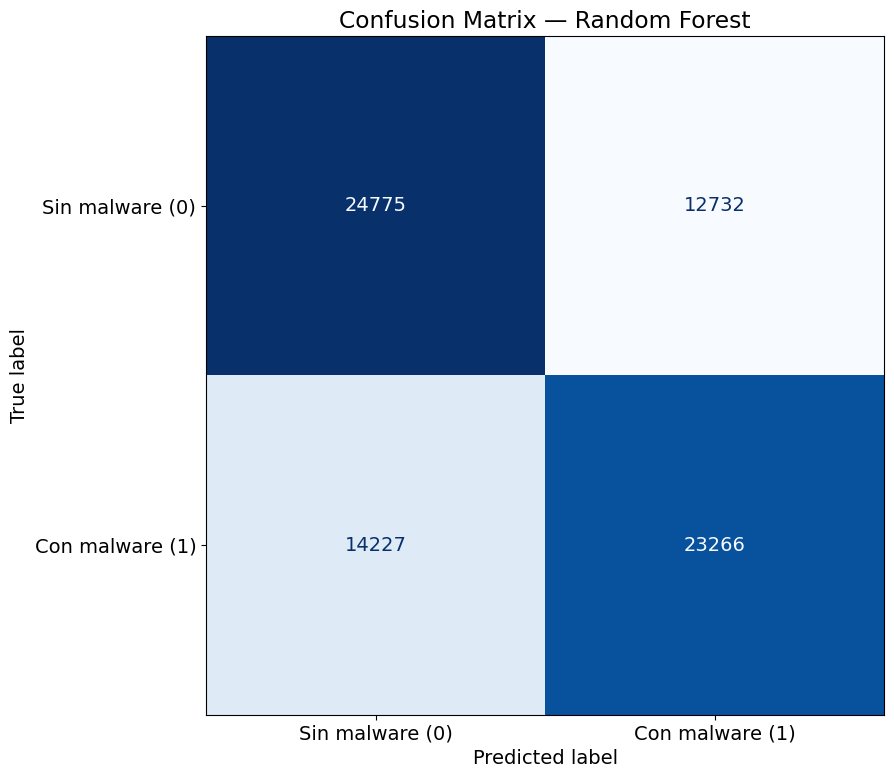

In [113]:
y_pred = Random_Forest_model_pipeline.predict(X_test)

acc_dt = accuracy_score(y_test, y_pred)
f1_dt  = f1_score(y_test, y_pred)
f2_dt = fbeta_score(y_test, y_pred, beta=2) # Beta=2 para darle más peso a los falsos negativos
cm_dt  = confusion_matrix(y_test, y_pred)


print("=== Random Forest — Validación ===\n")
print(f"Accuracy : {acc_dt:.4f}")
print(f"F1 Score : {f1_dt:.4f}")
print(f"F2 Score : {f2_dt:.4f}")

print(f"\nVerdaderos Negativos  (TN): {cm_dt[0,0]:,}")
print(f"Falsos Positivos      (FP): {cm_dt[0,1]:,}")
print(f"Escapes               (FN): {cm_dt[1,0]:,}")
print(f"Virus Cazados         (TP): {cm_dt[1,1]:,}")

fig, ax = plt.subplots(figsize=(9, 8))
ConfusionMatrixDisplay(confusion_matrix=cm_dt, display_labels=['Sin malware (0)', 'Con malware (1)']).plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix — Random Forest')
plt.tight_layout()
plt.show()


#### 7.1.2. Tuning Hiperparámetros RandomForest y obtención del BestRF

- Dados los resultados del primer modelo, más Falsos negativos que positivos,  se va a buscar premiar la reducción de Falsos Negativos.

In [ ]:
# Submuestra reducida para acelerar el tuning
sample_idx = np.random.RandomState(42).choice(len(X_train), size=50_000, replace=False)
X_tune = X_train.iloc[sample_idx]
y_tune = y_train.iloc[sample_idx]

param_dist = {
    "model__n_estimators"     : [100, 200],
    "model__max_depth"        : [10, 20, None],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf" : [1, 4],
    "model__max_features"     : ['sqrt', 'log2'],
    "model__class_weight"     : [None, 'balanced'],
}

rf_pipe = Pipeline([
    ("preprocessing", preprocessor2),
    ("model", RandomForestClassifier(random_state=42, n_jobs=-1))
])

rf_search = RandomizedSearchCV(
    estimator           = rf_pipe,
    param_distributions = param_dist,
    n_iter              = 10,
    scoring             = 'recall',
    cv                  = 2,
    random_state        = 42,
    verbose             = 2,
    n_jobs              = -1,
)

rf_search.fit(X_tune, y_tune)

print(f"\nMejores parámetros: {rf_search.best_params_}")
print(f"Mejor recall (CV) : {rf_search.best_score_:.4f}")

Fitting 2 folds for each of 10 candidates, totalling 20 fits

Mejores parámetros: {'model__n_estimators': 100, 'model__min_samples_split': 2, 'model__min_samples_leaf': 1, 'model__max_features': 'log2', 'model__max_depth': 10, 'model__class_weight': None}
Mejor recall (CV) : 0.6924


#### 7.1.3. Best RF análisis

- Se mejora la detección de Falsos Negativos y se procede a seleccionar 0.4 como threshold, siguiendo una estrategia de negocio de minimización de malware no detectado.

- Además se distribuye de forma más equitativa la importancia entre las diferentes columnas.

In [97]:
# Reentrenamos con los mejores parámetros sobre todo el train transformado
best_rf_pipe = rf_search.best_estimator_

y_pred_best_rf = best_rf_pipe.predict(X_test)

acc_rf_tuned = accuracy_score(y_test, y_pred_best_rf)
f1_rf_tuned  = f1_score(y_test, y_pred_best_rf)
f2_rf_tuned  = fbeta_score(y_test, y_pred_best_rf, beta=2)
cm_rf_tuned  = confusion_matrix(y_test, y_pred_best_rf)

thresholds = np.linspace(0, 1, 101)
probs = best_rf_pipe.predict_proba(X_test)[:, 1]

f1_scores = [f1_score(y_test, probs > t) for t in thresholds]
f2_scores = [fbeta_score(y_test, probs > t, beta=2) for t in thresholds]

best_f1_idx = np.argmax(f1_scores)
best_f2_idx = np.argmax(f2_scores)

best_threshold_f1 = thresholds[best_f1_idx]
best_threshold_f2 = thresholds[best_f2_idx]

print("Best F1 threshold:", best_threshold_f1)
print("Best F2 threshold:", best_threshold_f2)

print("=== Decision Tree Tuneado - Validacion ===")
print()
print(f"Accuracy : {acc_dt_tuned:.4f}")
print(f"F1 Score : {f1_dt_tuned:.4f}")
print(f"F2 Score : {f2_dt_tuned:.4f}")
print(f"\nVerdaderos Negativos  (TN): {cm_dt_tuned[0,0]:,}")
print(f"Falsos Positivos      (FP): {cm_dt_tuned[0,1]:,}")
print(f"Falsos Negativos      (FN): {cm_dt_tuned[1,0]:,}")
print(f"Verdaderos Positivos  (TP): {cm_dt_tuned[1,1]:,}")

Best F1 threshold: 0.41000000000000003
Best F2 threshold: 0.27
=== Decision Tree Tuneado - Validacion ===

Accuracy : 0.6158
F1 Score : 0.6310
F2 Score : 0.6465

Verdaderos Negativos  (TN): 21,542
Falsos Positivos      (FP): 15,965
Falsos Negativos      (FN): 12,853
Verdaderos Positivos  (TP): 24,640


In [116]:
# Ajuste del umbral de clasificacion para reducir FN
# Criterio: minimizar FN (prioridad de negocio en detección de malware)
y_proba_best_rf = best_rf_pipe.predict_proba(X_test)[:, 1]

print(f"{'Threshold':<12} {'Accuracy':>10} {'F1':>10} {'F2':>10} {'FN':>10} {'FP':>10}")
print("-" * 68)

for threshold in [0.6, 0.55, 0.5, 0.45, 0.4, 0.35, 0.3, 0.25]:
    y_pred_t = (y_proba_best_rf >= threshold).astype(int)
    cm_t = confusion_matrix(y_test, y_pred_t)
    f1_t = f1_score(y_test, y_pred_t)
    f2_rf = fbeta_score(y_test, y_pred_t, beta=2)
    print(f"{threshold:<12} {accuracy_score(y_test, y_pred_t):>10.4f} {f1_t:>10.4f} {f2_rf:>10.4f} {cm_t[1,0]:>10,} {cm_t[0,1]:>10,}")

# Threshold elegido: 0.4 — minimiza FN (dispositivos infectados no detectados)
# En seguridad, un FN es más costoso que un FP
best_threshold_rf = 0.4
print(f"\nThreshold seleccionado: {best_threshold_rf} (criterio: minimizar FN)")

Threshold      Accuracy         F1         F2         FN         FP
--------------------------------------------------------------------
0.6              0.5607     0.2546     0.1795     31,867      1,081
0.55             0.6095     0.5345     0.4794     20,674      8,616
0.5              0.6177     0.6451     0.6742     11,431     17,239
0.45             0.6060     0.6671     0.7356      7,885     21,666
0.4              0.5673     0.6803     0.8068      2,966     29,483
0.35             0.5198     0.6723     0.8306        551     35,466
0.3              0.5037     0.6677     0.8330         89     37,136
0.25             0.5006     0.6668     0.8333          9     37,447

Threshold seleccionado: 0.4 (criterio: minimizar FN)


=== Top 20 features — Random Forest ===

                                                       feature  importance
                             low_cat__SmartScreen_ExistsNotSet    0.110600
                           high_cat__AVProductStatesIdentifier    0.069783
                              low_cat__AVProductsInstalled_1.0    0.040631
                                 low_cat__av_enabled_ratio_1.0    0.039155
                              low_cat__AVProductsInstalled_2.0    0.033591
                                 low_cat__av_enabled_ratio_0.5    0.033129
                             low_cat__SmartScreen_RequireAdmin    0.032180
                            low_cat__EngineVersion_1.1.15100.1    0.020856
                 num__median__Census_SystemVolumeTotalCapacity    0.018347
num__median__Census_InternalPrimaryDiagonalDisplaySizeInInches    0.018155
                  num__median__Census_PrimaryDiskTotalCapacity    0.016959
                          num__median__Census_TotalPhysical

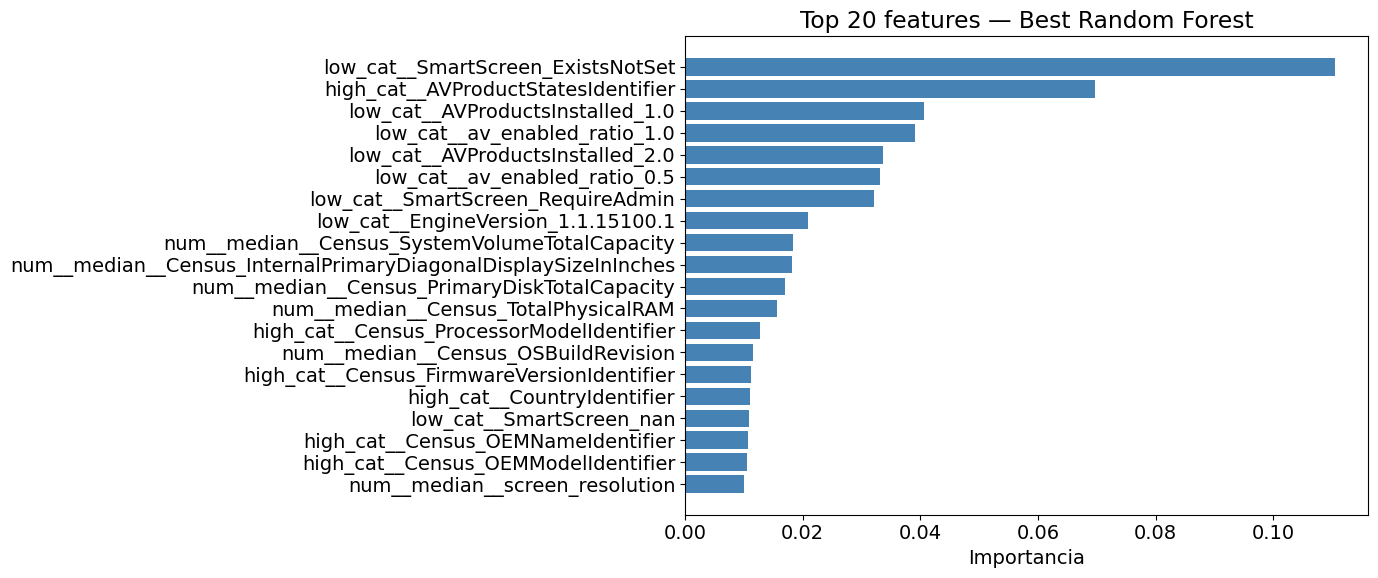

In [98]:
# Feature importance del Decision Tree tuneado
# Con OHE, los nombres de columnas los obtenemos del preprocessor
X_train_trans = best_rf_pipe.named_steps["preprocessing"].transform(X_train)
feature_names_best_rf = X_train_trans.columns.tolist()

fi_best_rf = pd.Series(
    best_rf_pipe.named_steps["model"].feature_importances_,
    index=feature_names_best_rf
).sort_values(ascending=False)
fi_best_rf_df = fi_best_rf.reset_index()
fi_best_rf_df.columns = ['feature', 'importance']

print("=== Top 20 features — Random Forest ===\n")
print(fi_best_rf_df.head(20).to_string(index=False))

# Plot
top_n = 20
fi_best_rf_top = fi_best_rf_df.head(top_n)

fig, ax = plt.subplots(figsize=(14, 6))
ax.barh(fi_best_rf_top['feature'][::-1], fi_best_rf_top['importance'][::-1], color='steelblue')
ax.set_xlabel('Importancia')
ax.set_title(f'Top {top_n} features — Best Random Forest')
plt.tight_layout()
plt.show()

### 7.1.4. Conclusiones RF

In [117]:
comparativa_real = []

# A. Dummy (Baseline) - Calculado sobre la marcha
from sklearn.dummy import DummyClassifier
dummy = DummyClassifier(strategy="most_frequent").fit(X_train, y_train)
y_pred_dummy = dummy.predict(X_val)
comparativa_real.append({
    "Modelo": "Dummy (baseline)",
    "Accuracy": accuracy_score(y_val, y_pred_dummy),
    "F1": f1_score(y_val, y_pred_dummy, zero_division=0),
    "FN": "—"
})

# B. RF base (El primero que entrenamos con threshold 0.5)

y_pred_rf_base = Random_Forest_model_pipeline.predict(X_val)
cm_base = confusion_matrix(y_val, y_pred_rf_base)
comparativa_real.append({
    "Modelo": "RF base (threshold=0.5)",
    "Accuracy": accuracy_score(y_val, y_pred_rf_base),
    "F1": f1_score(y_val, y_pred_rf_base),
    "FN": f"{cm_base[1,0]:,}"
})

# C. Best RF (El mejor_rf tras RandomizedSearch con threshold 0.4)
y_prob_tuneado = best_rf_pipe.predict_proba(X_val)[:, 1]
y_pred_tuneado_best_th = (y_prob_tuneado >= best_threshold_rf).astype(int)
cm_tuneado = confusion_matrix(y_val, y_pred_tuneado_best_th)
comparativa_real.append({
    "Modelo": "RF tuneado (threshold=0.4)",
    "Accuracy": accuracy_score(y_val, y_pred_tuneado_best_th),
    "F1": f1_score(y_val, y_pred_tuneado_best_th),
    "FN": f"{cm_tuneado[1,0]:,}"
})


# --- IMPRESIÓN DE LA TABLA FORMATEADA ---
print("=== COMPARATIVA RF COMPLETA (VALORES REALES) ===")
print("-" * 75)
print(f"{'Modelo':<35} {'Accuracy':<12} {'F1':<10} {'FN (Escapes)':<15}")
print("-" * 75)

for m in comparativa_real:
    acc_str = f"{m['Accuracy']:.4f}" if isinstance(m['Accuracy'], float) else m['Accuracy']
    f1_str = f"{m['F1']:.4f}" if isinstance(m['F1'], float) else m['F1']
    print(f"{m['Modelo']:<35} {acc_str:<12} {f1_str:<10} {m['FN']:<15}")

print("-" * 75)

=== COMPARATIVA RF COMPLETA (VALORES REALES) ===
---------------------------------------------------------------------------
Modelo                              Accuracy     F1         FN (Escapes)   
---------------------------------------------------------------------------
Dummy (baseline)                    0.5001       0.0000     —              
RF base (threshold=0.5)             0.6411       0.6332     14,264         
RF tuneado (threshold=0.4)          0.5674       0.6804     2,953          
---------------------------------------------------------------------------


### 7.2. LightGBM

- Implementación del modelo LightGBM para comparar resultados

- Llama la atención el cambio de orden de importancia de variables. Por ejemplo, 'SmartScreen' pasa de ser la más importante en DT y RF, a la séptima más importante en LightGBM.

In [100]:
import re

class CleanFeatureNames(BaseEstimator, TransformerMixin):

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = pd.DataFrame(X).copy()

        X.columns = [
            re.sub(r"[^0-9a-zA-Z_]", "_", str(col))
            for col in X.columns
        ]

        return X

c:\Users\jonmi\AppData\Local\Programs\Python\Python313\Lib\site-packages\lightgbm\basic.py:2137: UserWarning: categorical_feature keyword has been found in `params` and will be ignored.
Please use categorical_feature argument of the Dataset constructor to pass this parameter.
  _log_warning(


=== LightGBM (threshold=0.5) — Validación ===

Accuracy : 0.6465
F1 Score : 0.6437
F2 Score : 0.6407
FN       : 13,546
FP       : 12,968


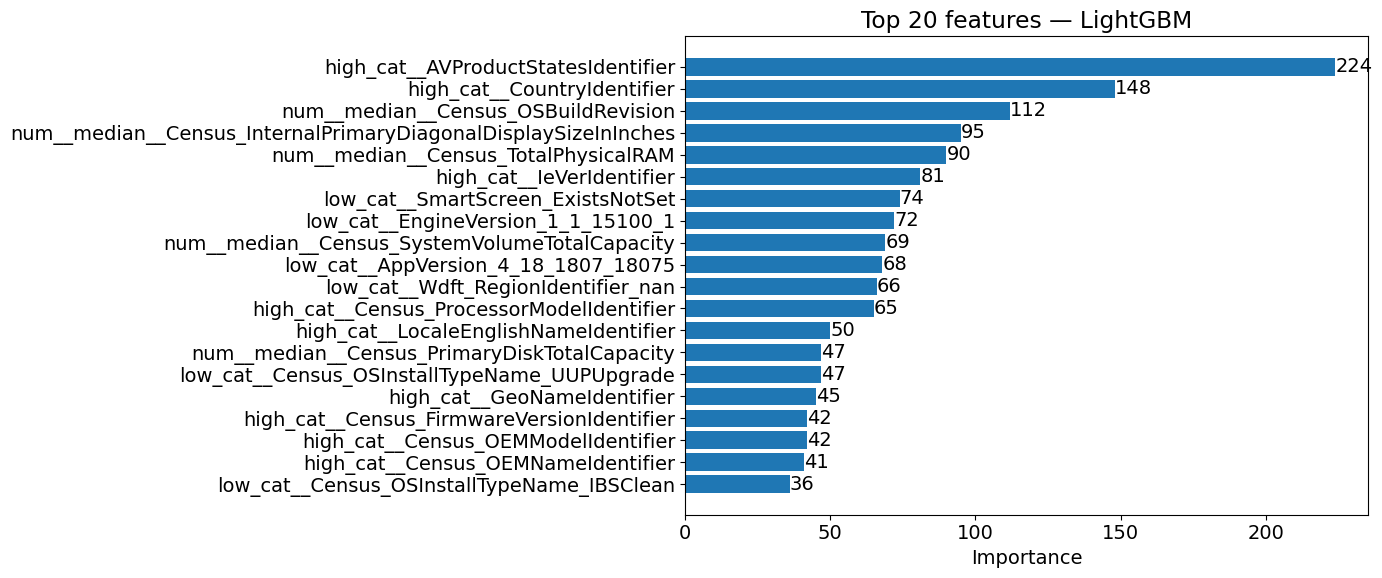

In [114]:
from lightgbm import LGBMClassifier

# Entrenamiento LightGBM con los mismos datos transformados
lgbm = LGBMClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    verbosity=-1,
    categorical_feature=None   # force no categorical features
)

lgbm_pipe = Pipeline([
    ("preprocessing", preprocessor2),
    ("clean_names", CleanFeatureNames()),
    ("model", lgbm)
])


lgbm_pipe.fit(X_train, y_train)

# Evaluación en validación con threshold=0.5
y_pred_lgbm = lgbm_pipe.predict(X_test)
acc_lgbm = accuracy_score(y_test, y_pred_lgbm)
f1_lgbm  = f1_score(y_test, y_pred_lgbm)
f2_lgbm  = fbeta_score(y_test, y_pred_lgbm, beta=2)
cm_lgbm  = confusion_matrix(y_test, y_pred_lgbm)

print("=== LightGBM (threshold=0.5) — Test ===\n")
print(f"Accuracy : {acc_lgbm:.4f}")
print(f"F1 Score : {f1_lgbm:.4f}")
print(f"F2 Score : {f2_lgbm:.4f}")
print(f"FN       : {cm_lgbm[1,0]:,}")
print(f"FP       : {cm_lgbm[0,1]:,}")


# Feature importance de LightGBM


X_train_trans = lgbm_pipe.named_steps["clean_names"].transform(
    lgbm_pipe.named_steps["preprocessing"].transform(X_train)
)

feature_names = X_train_trans.columns

fi_lgbm = pd.Series(
    lgbm_pipe.named_steps["model"].feature_importances_,
    index=feature_names
).sort_values(ascending=False)


top_n = 20
fi_top = fi_lgbm.head(top_n)

fig, ax = plt.subplots(figsize=(14,6))

ax.barh(fi_top.index[::-1], fi_top.values[::-1])

for i, v in enumerate(fi_top.values[::-1]):
    ax.text(v, i, f"{v:.0f}", va="center")

ax.set_title(f"Top {top_n} features — LightGBM")
ax.set_xlabel("Importance")

plt.tight_layout()
plt.show()


# Comparativa con el mejor RF
# print("\n=== Comparativa ===\n")
# print(f"{'Modelo':<35} {'Accuracy':>10} {'F1':>10} {'F2':>10} {'FN':>10}")
# print("-" * 78)
# print(f"{'RF tuneado + FE (0.45)':<35} {0.6206:>10.4f} {0.6734:>10.4f} {f2_final:>10.4f} {8290:>10,}")
# print(f"{'LightGBM (0.5)':<35} {acc_lgbm:>10.4f} {f1_lgbm:>10.4f} {f2_lgbm:>10.4f} {cm_lgbm[1,0]:>10,}")

## 8. Conclusiones

### Tarea
Clasificación para detectar malware en dispositivos Windows (`HasDetections`: 0 = sin malware, 1 = con malware). Dataset balanceado (~50% por clase, ~500 k dispositivos).

### Modelo principal: Decision Tree

El Decision Tree tuneado es el modelo central de este trabajo. Tras optimizar sus hiperparámetros con `RandomizedSearchCV` y ajustar el umbral de clasificación, los resultados en validación son:

In [128]:
# === COMPARATIVA DT COMPLETA (VALORES REALES) ===
# ---------------------------------------------------------------------------
# Modelo                              Accuracy     F1         FN (Escapes)   
# ---------------------------------------------------------------------------
# Dummy (baseline)                    0.5001       0.0000     —              
# DT base (threshold=0.5)             0.6216       0.6411     12,141         
# DT tuneado (threshold=0.4)          0.5930       0.6689     6,654          
# ---------------------------------------------------------------------------

### Razonamiento de negocio: por qué threshold=0.40

En detección de malware, **un Falso Negativo (FN) es mucho más costoso que un Falso Positivo (FP)**:
- **FN**: un dispositivo infectado pasa desapercibido → el malware actúa sin restricciones, puede propagarse y robar datos.
- **FP**: un dispositivo limpio recibe una alerta → el usuario revisa innecesariamente, pero no hay daño real.

Bajar el threshold de 0.50 a **0.40** reduce los FN de 12,141 a **6,654**, con una pérdida de accuracy de solo 3 puntos. El F1 mejora (0.6411 → 0.6689) porque la ganancia en recall compensa la caída en precision. Este trade-off es claramente favorable en un contexto de seguridad. 

### Curva ROC_AUC

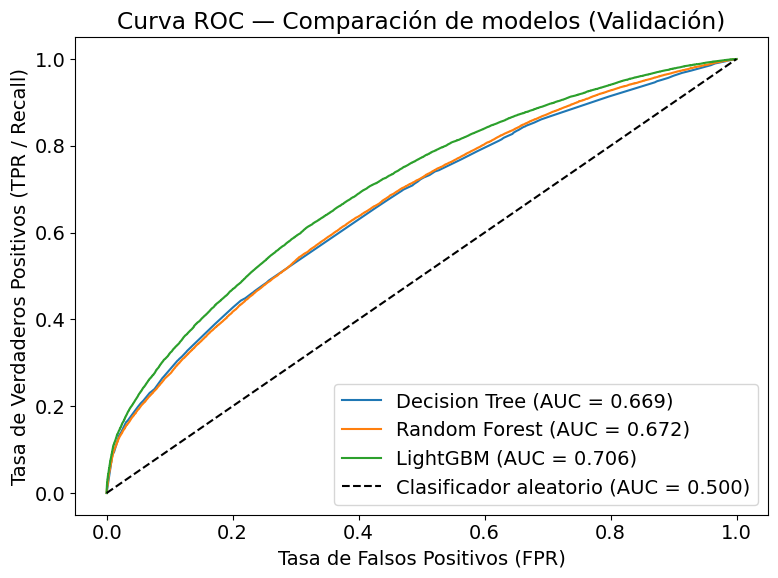

In [ ]:
from sklearn.metrics import roc_curve, auc

# Probabilidades de clase positiva (malware) en validación
y_prob_dt   = best_dt_pipe.predict_proba(X_val)[:, 1]
y_prob_rf   = best_rf_pipe.predict_proba(X_val)[:, 1]
y_prob_lgbm = lgbm_pipe.predict_proba(X_val)[:, 1]

fig, ax = plt.subplots(figsize=(8, 6))
for name, y_prob in [
    ("Decision Tree", y_prob_dt),
    ("Random Forest", y_prob_rf),
    ("LightGBM",      y_prob_lgbm),
]:
    fpr, tpr, _ = roc_curve(y_val, y_prob)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.3f})")

ax.plot([0, 1], [0, 1], 'k--', label='Clasificador aleatorio (AUC = 0.500)')
ax.set_xlabel('Tasa de Falsos Positivos (FPR)')
ax.set_ylabel('Tasa de Verdaderos Positivos (TPR / Recall)')
ax.set_title('Curva ROC — Comparación de modelos (Validación)')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()


### Experimentación adicional

Como extensión, se probaron Random Forest y LightGBM sobre los mismos datos transformados:

| Modelo | Accuracy (val) | F1 (val) | FN (val) | AUC |
|---|---|---|---|---|
| DT tuneado (`threshold=0.40`) | 0.5930 | 0.6689 | 6,654 | 0.669 |
| RF tuneado (`threshold=0.40`) | 0.5674 | 0.6804 | 2,953 | 0.672 |
| LightGBM (`threshold=0.50`) | 0.6465 | 0.6437 | 13,546 | 0.706 |

LightGBM mejora el AUC respecto a DT y RF (0.706 vs 0.669 y 0.672), pero con threshold por defecto genera muchos más FN. LightGBM es también el más eficiente computacionalmente.

### Conclusión final
El **Decision Tree con threshold=0.40** es la propuesta principal: reduce los Falsos Negativos un 45.2% respecto al threshold por defecto, mantiene un F1 de 0.6689. Si el objetivo fuera minimizar FN de forma aún más agresiva manteniendo AUC alto, LightGBM con threshold ajustado sería la alternativa a explorar.

### Líneas de mejoras futuras
- Feature engineering: interacciones entre variables de sistema y versiones de software
- Validación y training con datasets actualizados